In [1]:
# Cell 1 — Imports, shared constants, and user controls  # Define the top-of-notebook settings used by every later cell.
from pathlib import Path  # Import Path so file-system paths are easy to read and join safely.
import json  # Import json so small settings files can be saved in a readable format.
import itertools  # Import itertools so pairwise group comparisons are easy to build later.
import ast  # Import ast so tuple-like metadata strings can be parsed safely.
from datetime import datetime  # Import datetime so default output folders can use readable timestamps.
import math  # Import math so standard-error calculations are easy to express.
import numpy as np  # Import numpy so array work and numeric calculations are easy.
import pandas as pd  # Import pandas so tables can be loaded, merged, and saved cleanly.
import zarr  # Import zarr so the dataset image array can be checked without full loading.
import matplotlib.pyplot as plt  # Import matplotlib so summary figures can be created and saved.
import ipywidgets as widgets  # Import ipywidgets so the run-selection interface stays interactive.
from IPython.display import display, HTML, clear_output  # Import notebook display helpers for widgets and tables.
from sklearn.metrics import confusion_matrix  # Import confusion_matrix so confusion tables can be built from labels.
# ---  # Separate the code into small readable sections.
pd.set_option("display.max_columns", 200)  # Show many columns when wide summary tables are displayed inline.
pd.set_option("display.max_rows", 200)  # Show enough rows to inspect selected-run tables without truncating too early.
pd.set_option("display.width", 180)  # Make printed tables wrap less often in the notebook output area.
# ---  # Separate the code into small readable sections.
CLASS_ORDER = ["gray_d", "gray_l", "red", "green", "blue", "yellow"]  # Define the canonical source-label order used by the saved runs.
LABEL_TO_INT = {label: idx for idx, label in enumerate(CLASS_ORDER)}  # Build a text-to-integer label map for reconstruction work.
INT_TO_LABEL = {idx: label for label, idx in LABEL_TO_INT.items()}  # Build the reverse integer-to-text label map for display work.
# ---  # Separate the code into small readable sections.
COMBINE_GRAY_CLASSES = True  # Choose whether gray_d and gray_l are merged into one evaluation class called gray.
LOAD_SAVED_RESULTS_ONLY = False  # Choose whether the notebook reloads previously saved notebook outputs instead of recomputing them.
AGGREGATION_METHOD = "pooled_counts"  # Choose "mean_percent" to average row-normalized run matrices or "pooled_counts" to pool counts first.
SHOW_STD_ERROR_BARS = True  # Choose whether the accuracy and contrast summary plots include standard-deviation error bars.
SHOW_SEM_ERROR_BARS = True  # Choose whether the accuracy and contrast summary plots include standard-error-of-the-mean error bars.
INCLUDE_CONTRAST_ANALYSIS = True  # Choose whether the delta brightness, saturation, and hue analyses are built and saved.
LABEL_SOURCE_SUFFIX = "auto_labels"  # Use one fixed label-source text because this revised notebook no longer supports human review.
EVAL_CLASS_ORDER = ["gray", "red", "green", "blue", "yellow"] if COMBINE_GRAY_CLASSES else list(CLASS_ORDER)  # Build the active evaluation class order from the gray-choice setting.
EVAL_MODE_SUFFIX = "gray_merged" if COMBINE_GRAY_CLASSES else "separate_gray"  # Build one short text label for the gray-handling choice.
NOTEBOOK_SUMMARY_FILE_NAME = "confusion_summary_long.csv"  # Use one shared long-summary filename so this notebook matches the CNN notebook format.
EVAL_OUTPUT_FOLDER_NAME = "evaluation_outputs"  # Use one shared figure-output folder name so this notebook matches the CNN notebook format.
# ---  # Separate the code into small readable sections.
RESULTS_ROOT = Path(".")  # Point to the folder that contains the saved MLR, SVM, and RF result folders.
DATASET_RUN_DIR = Path("export_retina_20260313_230715")  # Point to the dataset folder that contains metadata.csv and dataset.zarr.
ZARR_PATH = DATASET_RUN_DIR / "dataset.zarr"  # Build the dataset.zarr path from the dataset folder.
META_PATH = DATASET_RUN_DIR / "metadata.csv"  # Build the metadata.csv path from the dataset folder.
NOTEBOOK_OUTPUT_PARENT = Path(".")  # Point to the parent folder where this revised notebook will save its own outputs.
DEFAULT_OUTPUT_DIR_NAME = "mlr_svm_rf_compare_" + datetime.now().strftime("%Y%m%d_%H%M%S")  # Build a readable default notebook-output folder name.
# ---  # Separate the code into small readable sections.
print("RESULTS_ROOT:", RESULTS_ROOT.resolve())  # Show the resolved results-root path for quick checking.
print("DATASET_RUN_DIR:", DATASET_RUN_DIR.resolve())  # Show the resolved dataset folder path for quick checking.
print("META_PATH:", META_PATH.resolve())  # Show the resolved metadata path for quick checking.
print("ZARR_PATH:", ZARR_PATH.resolve())  # Show the resolved dataset.zarr path for quick checking.
print("NOTEBOOK_OUTPUT_PARENT:", NOTEBOOK_OUTPUT_PARENT.resolve())  # Show where this notebook will save its own outputs.
print("Gray handling mode:", EVAL_MODE_SUFFIX)  # Show the active gray-handling mode at the top of the notebook.
print("Aggregation method:", AGGREGATION_METHOD)  # Show the active confusion-matrix aggregation method at the top of the notebook.
print("Contrast analysis enabled:", INCLUDE_CONTRAST_ANALYSIS)  # Show whether the contrast-analysis block is enabled.

RESULTS_ROOT: /data/retina-neitz/notebooks
DATASET_RUN_DIR: /data/retina-neitz/notebooks/export_retina_20260313_230715
META_PATH: /data/retina-neitz/notebooks/export_retina_20260313_230715/metadata.csv
ZARR_PATH: /data/retina-neitz/notebooks/export_retina_20260313_230715/dataset.zarr
NOTEBOOK_OUTPUT_PARENT: /data/retina-neitz/notebooks
Gray handling mode: gray_merged
Aggregation method: pooled_counts
Contrast analysis enabled: True


In [2]:
# Cell 2 — Load metadata and validate the dataset structure  # Load the metadata table once and confirm the saved dataset is aligned.
if not META_PATH.exists():  # Stop early if the metadata table is missing.
    raise FileNotFoundError("META_PATH was not found: " + str(META_PATH))  # Explain exactly which required file is missing.
if not ZARR_PATH.exists():  # Stop early if the dataset.zarr folder is missing.
    raise FileNotFoundError("ZARR_PATH was not found: " + str(ZARR_PATH))  # Explain exactly which required dataset path is missing.
# ---  # Separate the code into small readable sections.
root = zarr.open_group(str(ZARR_PATH), mode="r")  # Open the dataset.zarr group in read-only mode.
imgs_z = root["imgs"]  # Open the saved image array without loading the whole dataset into memory.
META_DF = pd.read_csv(META_PATH).copy()  # Load the metadata table into one dedicated dataframe copy.
META_DF["stim_ID"] = pd.to_numeric(META_DF["stim_ID"], errors="coerce")  # Convert stim_ID values to numeric form for safe indexing.
META_DF = META_DF.loc[~META_DF["stim_ID"].isna()].copy()  # Drop rows that do not have a valid stim_ID value.
META_DF["stim_ID"] = META_DF["stim_ID"].astype(np.int64)  # Convert stim_ID values to integer type after invalid rows are removed.
META_DF = META_DF.sort_values("stim_ID", kind="mergesort").reset_index(drop=True)  # Put the metadata rows into stable stim_ID order.
# ---  # Separate the code into small readable sections.
unknown_labels = sorted(set(META_DF["true_label"].astype(str).unique()) - set(CLASS_ORDER))  # Find any labels that are not part of the expected source-label order.
if len(unknown_labels) > 0:  # Stop if the metadata table contains unexpected true labels.
    raise ValueError("metadata.csv contains unexpected true_label values: " + str(unknown_labels))  # Explain exactly which labels caused the failure.
# ---  # Separate the code into small readable sections.
expected_stim_ids = np.arange(int(imgs_z.shape[0]), dtype=np.int64)  # Build the expected stim_ID order implied by the first image axis.
actual_stim_ids = META_DF["stim_ID"].to_numpy(dtype=np.int64)  # Read the actual ordered stim_ID values from the metadata table.
if not np.array_equal(actual_stim_ids, expected_stim_ids):  # Stop if the metadata order does not match the saved image order.
    raise ValueError("metadata.csv stim_ID order does not exactly match the first axis of dataset.zarr.")  # Explain why the dataset alignment check failed.
# ---  # Separate the code into small readable sections.
META_DF["true_label"] = META_DF["true_label"].astype(str)  # Normalize the source true-label column as plain text.
META_DF["true_label_int"] = META_DF["true_label"].map(LABEL_TO_INT).astype(np.int64)  # Add the integer source-label column used in later reconstruction steps.
META_INDEXED_DF = META_DF.set_index("stim_ID", drop=True).copy()  # Keep one stim_ID-indexed metadata table for fast test-split lookup later.
# ---  # Separate the code into small readable sections.
print("Dataset image shape:", tuple(int(v) for v in imgs_z.shape))  # Show the saved image-array shape for quick inspection.
print("Metadata rows:", len(META_DF))  # Show how many metadata rows are available.
print("Source labels:", META_DF["true_label"].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int).to_dict())  # Show class counts in canonical label order.

Dataset image shape: (4710, 1000, 1000, 3)
Metadata rows: 4710
Source labels: {'gray_d': 925, 'gray_l': 925, 'red': 715, 'green': 715, 'blue': 715, 'yellow': 715}


In [3]:
# Cell 3 — Helper functions and scan of the saved result folders  # Define reusable helpers, compute stimulus deltas, and scan the results root.
# ---  # Separate the code into small readable sections.
def sanitize_name(text):  # Convert free text into a simple filename-safe string.
    cleaned_text = str(text).strip().replace(" ", "_")  # Remove outer spaces and replace internal spaces with underscores.
    kept_chars = [char for char in cleaned_text if char.isalnum() or char in {"_", "-"}]  # Keep only simple filename-safe characters.
    safe_text = "".join(kept_chars).strip("_")  # Join the kept characters and trim extra underscores.
    return safe_text if safe_text != "" else "item"  # Return the cleaned name or a simple fallback when nothing valid remains.
# ---  # Separate the code into small readable sections.
def build_run_key(model_name, group_name, run_dir_name):  # Build one readable unique key for each saved run row.
    return f"{str(model_name)} | {str(group_name)} | {str(run_dir_name)}"  # Combine model, group, and folder name into one stable display key.
# ---  # Separate the code into small readable sections.
def evaluation_label_from_text(label_text):  # Convert one source label into the active evaluation label.
    normalized_label = str(label_text).strip()  # Normalize the incoming label as plain text before mapping.
    if COMBINE_GRAY_CLASSES and normalized_label in {"gray_d", "gray_l"}:  # Collapse both gray subclasses when gray merging is enabled.
        return "gray"  # Return the merged gray label for either gray subclass.
    return normalized_label  # Leave non-gray labels unchanged.
# ---  # Separate the code into small readable sections.
def parse_triplet_like(value):  # Convert a stored HSV-like text value into a numeric triplet when possible.
    if isinstance(value, (list, tuple, np.ndarray)) and len(value) >= 3:  # Use list-like inputs directly when they already contain three values.
        return [float(value[0]), float(value[1]), float(value[2])]  # Return the first three values as floats.
    if pd.isna(value):  # Return missing values when the input is empty.
        return [np.nan, np.nan, np.nan]  # Use a three-value NaN placeholder for missing triplets.
    text_value = str(value).strip()  # Normalize the incoming value as plain text before parsing.
    if text_value == "":  # Return missing values when the input text is blank.
        return [np.nan, np.nan, np.nan]  # Use a three-value NaN placeholder for blank triplets.
    try:  # Try the safest structured parser first.
        parsed_value = ast.literal_eval(text_value)  # Parse tuple-like or list-like text into a Python object safely.
        if isinstance(parsed_value, (list, tuple, np.ndarray)) and len(parsed_value) >= 3:  # Accept only triplet-like parsed values.
            return [float(parsed_value[0]), float(parsed_value[1]), float(parsed_value[2])]  # Return the first three parsed values as floats.
    except Exception:  # Fall through to the lightweight text parser when literal parsing fails.
        pass  # Continue into the text-based parsing path.
    text_value = text_value.replace("(", "").replace(")", "").replace("[", "").replace("]", "")  # Remove common bracket characters before splitting.
    parts = [part.strip() for part in text_value.replace(";", ",").split(",")]  # Split the text into comma-like pieces and trim spaces.
    numeric_parts = []  # Collect successfully parsed numeric values here.
    for part in parts:  # Read each split piece one at a time.
        if part == "":  # Skip empty pieces created by repeated separators.
            continue  # Move on to the next split piece.
        try:  # Try to convert the current piece into a float.
            numeric_parts.append(float(part))  # Save the parsed numeric value when conversion succeeds.
        except Exception:  # Ignore pieces that are not numeric.
            continue  # Move on to the next split piece when conversion fails.
    if len(numeric_parts) >= 3:  # Return a triplet when at least three numeric values were recovered.
        return [numeric_parts[0], numeric_parts[1], numeric_parts[2]]  # Return the first three numeric values as floats.
    return [np.nan, np.nan, np.nan]  # Return missing values when no reliable triplet could be parsed.
# ---  # Separate the code into small readable sections.
def circular_hue_distance(hue_a, hue_b):  # Compute the shortest distance between two hue values on the hue circle.
    if pd.isna(hue_a) or pd.isna(hue_b):  # Return missing values when either hue is missing.
        return np.nan  # Use NaN when a hue distance cannot be computed.
    hue_a = float(hue_a) % 1.0 if abs(float(hue_a)) <= 1.0 else float(hue_a) % 360.0  # Normalize the first hue into either a 0-to-1 or 0-to-360 cycle.
    hue_b = float(hue_b) % 1.0 if abs(float(hue_b)) <= 1.0 else float(hue_b) % 360.0  # Normalize the second hue into either a 0-to-1 or 0-to-360 cycle.
    cycle_size = 1.0 if max(abs(hue_a), abs(hue_b)) <= 1.0 else 360.0  # Choose the cycle size that matches the normalized hue scale.
    direct_gap = abs(hue_a - hue_b)  # Compute the direct linear gap between the two normalized hues.
    return min(direct_gap, cycle_size - direct_gap)  # Return the shorter circular distance around the hue wheel.
# ---  # Separate the code into small readable sections.
def first_numeric_series(df, candidate_names):  # Return the first numeric column among a list of candidate column names.
    for column_name in candidate_names:  # Check each candidate column name in order.
        if column_name in df.columns:  # Use the first candidate column that exists in the dataframe.
            return pd.to_numeric(df[column_name], errors="coerce")  # Convert the chosen column to numeric values and return it.
    return pd.Series(np.nan, index=df.index, dtype=float)  # Return a same-length NaN series when none of the candidates exists.
# ---  # Separate the code into small readable sections.
def build_stimulus_delta_df(meta_df):  # Build one standardized per-stimulus table of brightness, saturation, and hue differences.
    work_df = meta_df.copy()  # Work from a local copy so the original metadata table stays unchanged.
    delta_df = work_df[["stim_ID", "true_label"]].copy()  # Start the output with the core per-stimulus identifiers.
    delta_df["eval_true_label"] = delta_df["true_label"].map(evaluation_label_from_text)  # Add the evaluation-space true label after gray mapping.
    delta_df["delta_brightness"] = first_numeric_series(work_df, ["delta_int"]).abs()  # Prefer the saved delta_int column when it exists.
    if delta_df["delta_brightness"].isna().all():  # Fall back to object and background brightness columns when delta_int is unavailable.
        obj_int_series = first_numeric_series(work_df, ["obj_int", "object_int", "obj_brightness"])  # Read the object-brightness column from the best available name.
        bg_int_series = first_numeric_series(work_df, ["bg_int", "background_int", "bg_brightness"])  # Read the background-brightness column from the best available name.
        delta_df["delta_brightness"] = (obj_int_series - bg_int_series).abs()  # Compute absolute object-background brightness difference.
    delta_df["delta_saturation"] = first_numeric_series(work_df, ["delta_sat"]).abs()  # Prefer the saved delta_sat column when it exists.
    if delta_df["delta_saturation"].isna().all():  # Fall back to object and background saturation columns when delta_sat is unavailable.
        obj_sat_series = first_numeric_series(work_df, ["obj_sat", "object_sat"])  # Read the object-saturation column from the best available name.
        bg_sat_series = first_numeric_series(work_df, ["bg_sat", "background_sat"])  # Read the background-saturation column from the best available name.
        delta_df["delta_saturation"] = (obj_sat_series - bg_sat_series).abs()  # Compute absolute object-background saturation difference.
    delta_df["delta_hue"] = first_numeric_series(work_df, ["delta_hue"]).abs()  # Prefer a direct saved delta_hue column when it exists.
    if delta_df["delta_hue"].isna().all() and "delta_hsv" in work_df.columns:  # Fall back to parsing the saved delta_hsv column when needed.
        parsed_delta_hsv = work_df["delta_hsv"].apply(parse_triplet_like)  # Parse the stored delta_hsv values into numeric triplets.
        delta_df["delta_hue"] = pd.Series([abs(triplet[0]) if len(triplet) >= 1 else np.nan for triplet in parsed_delta_hsv], index=work_df.index, dtype=float)  # Use the first parsed component as hue difference.
    if delta_df["delta_hue"].isna().all() and {"obj_hue", "bg_hue"}.issubset(set(work_df.columns)):  # Fall back to direct hue columns when they are available.
        delta_df["delta_hue"] = [circular_hue_distance(hue_a, hue_b) for hue_a, hue_b in zip(pd.to_numeric(work_df["obj_hue"], errors="coerce"), pd.to_numeric(work_df["bg_hue"], errors="coerce"))]  # Compute circular hue distance from the direct object and background hue columns.
    if delta_df["delta_hue"].isna().all() and {"hsv_obj", "hsv_bg"}.issubset(set(work_df.columns)):  # Fall back to parsing full HSV object and background columns when needed.
        parsed_hsv_obj = work_df["hsv_obj"].apply(parse_triplet_like)  # Parse the stored object HSV values into numeric triplets.
        parsed_hsv_bg = work_df["hsv_bg"].apply(parse_triplet_like)  # Parse the stored background HSV values into numeric triplets.
        delta_df["delta_hue"] = [circular_hue_distance(obj_triplet[0], bg_triplet[0]) for obj_triplet, bg_triplet in zip(parsed_hsv_obj, parsed_hsv_bg)]  # Compute circular hue distance from the parsed HSV triplets.
    return delta_df  # Return the standardized per-stimulus delta table.
# ---  # Separate the code into small readable sections.
def initialize_output_dir(base_dir):  # Create the shared output-folder structure used by this revised notebook.
    base_dir = Path(base_dir)  # Convert the requested folder into a Path object for safe path joining.
    (base_dir / "summaries").mkdir(parents=True, exist_ok=True)  # Make the summaries folder used for long-format CSV tables.
    (base_dir / EVAL_OUTPUT_FOLDER_NAME).mkdir(parents=True, exist_ok=True)  # Make the evaluation-output folder used for saved figures and short tables.
    (base_dir / EVAL_OUTPUT_FOLDER_NAME / "difference_matrices").mkdir(parents=True, exist_ok=True)  # Make the difference-matrix subfolder used for pairwise comparison outputs.
    (base_dir / EVAL_OUTPUT_FOLDER_NAME / "contrast_analysis").mkdir(parents=True, exist_ok=True)  # Make the contrast-analysis subfolder used for delta h/s/brightness outputs.
    (base_dir / "manifests").mkdir(parents=True, exist_ok=True)  # Make the manifests folder used for saved selection and run-detail tables.
    return base_dir  # Return the confirmed base output folder path.
# ---  # Separate the code into small readable sections.
def resolve_artifact_path(results_root, run_dir, raw_path):  # Convert one stored relative artifact path into a real local path when possible.
    raw_text = str(raw_path).strip()  # Normalize the incoming path value as plain text.
    if raw_text == "" or raw_text.lower() == "nan":  # Return an empty path when the stored value is blank.
        return Path("")  # Use an empty path object when no real artifact path was saved.
    raw_item = Path(raw_text)  # Convert the stored path text into a Path object.
    candidates = []  # Collect path candidates in the order they should be checked.
    if raw_item.is_absolute():  # Keep an already absolute path as the first candidate.
        candidates.append(raw_item)  # Add the absolute path candidate.
    candidates.append(run_dir / raw_item.name)  # Try the file inside the run folder using just its filename.
    candidates.append(run_dir / raw_text)  # Try the raw stored relative path inside the run folder.
    candidates.append(results_root / raw_text)  # Try the raw stored relative path inside the results-root folder.
    for candidate in candidates:  # Check each candidate path in order.
        if candidate.exists():  # Stop when the first existing path is found.
            return candidate  # Return the first working local path.
    return Path("")  # Return an empty path when no candidate location exists.
# ---  # Separate the code into small readable sections.
def build_test_df(meta_indexed_df, test_idx):  # Build one final-test metadata table in the saved test order.
    ordered_df = meta_indexed_df.loc[np.asarray(test_idx, dtype=np.int64)].copy()  # Select the metadata rows in exactly the saved test order.
    ordered_df = ordered_df.reset_index()  # Restore stim_ID as a normal column for easier merges.
    ordered_df.insert(0, "test_pos", np.arange(len(ordered_df), dtype=np.int64))  # Add the position of each item within the final test set.
    return ordered_df  # Return the ordered test-set metadata table.
# ---  # Separate the code into small readable sections.
def load_misclassified_df(run_row, test_df):  # Load the misclassified table for one selected run and align it to the ordered test set.
    misclassified_path = Path(run_row["misclassified_path"])  # Read the stored misclassified path for this run.
    if not misclassified_path.exists():  # Stop when the saved misclassified file is not available for a selected run.
        raise FileNotFoundError("The required misclassified CSV was not found for run " + str(run_row["run_key"]) + ": " + str(misclassified_path))  # Explain exactly which selected run is missing its required file.
    misclassified_df = pd.read_csv(misclassified_path).copy()  # Load the saved misclassified rows into a local dataframe copy.
    if "stim_ID" not in misclassified_df.columns and "stim_id" in misclassified_df.columns:  # Normalize the stim_ID column name when an older lowercase name is present.
        misclassified_df = misclassified_df.rename(columns={"stim_id": "stim_ID"})  # Rename the lowercase stim_ID column to the canonical name.
    if "pred_label" not in misclassified_df.columns and "computer_pred_label" in misclassified_df.columns:  # Normalize the predicted-label column name when an alternate name is present.
        misclassified_df = misclassified_df.rename(columns={"computer_pred_label": "pred_label"})  # Rename the alternate prediction column to the canonical name.
    if "true_label" not in misclassified_df.columns and "auto_true_label" in misclassified_df.columns:  # Normalize the true-label column name when an alternate name is present.
        misclassified_df = misclassified_df.rename(columns={"auto_true_label": "true_label"})  # Rename the alternate true-label column to the canonical name.
    misclassified_df["stim_ID"] = pd.to_numeric(misclassified_df["stim_ID"], errors="coerce")  # Convert stim_ID values to numeric form for safe matching.
    misclassified_df = misclassified_df.loc[~misclassified_df["stim_ID"].isna()].copy()  # Drop rows that still lack a valid stim_ID value.
    misclassified_df["stim_ID"] = misclassified_df["stim_ID"].astype(np.int64)  # Convert the surviving stim_ID values to integer type.
    if "test_pos" not in misclassified_df.columns:  # Rebuild test_pos when the saved misclassified file did not include it.
        misclassified_df = misclassified_df.merge(test_df[["stim_ID", "test_pos"]], on="stim_ID", how="left")  # Recover the test positions by joining onto the ordered test table.
    misclassified_df["test_pos"] = pd.to_numeric(misclassified_df["test_pos"], errors="coerce")  # Convert test_pos values to numeric form for safe indexing.
    misclassified_df = misclassified_df.loc[~misclassified_df["test_pos"].isna()].copy()  # Drop rows that still lack a valid test position.
    misclassified_df["test_pos"] = misclassified_df["test_pos"].astype(np.int64)  # Convert the surviving test_pos values to integer type.
    misclassified_df["pred_label"] = misclassified_df["pred_label"].astype(str)  # Normalize the predicted-label column as plain text.
    if "true_label" in misclassified_df.columns:  # Normalize the saved true-label column when it is present.
        misclassified_df["true_label"] = misclassified_df["true_label"].astype(str)  # Convert the saved true-label column to plain text.
    misclassified_df = misclassified_df.sort_values(["test_pos", "stim_ID"], kind="mergesort").drop_duplicates(subset=["test_pos"], keep="last").reset_index(drop=True)  # Put the misclassified rows into stable test order and keep one row per test position.
    return misclassified_df  # Return the cleaned misclassified table.
# ---  # Separate the code into small readable sections.
def build_prediction_df(run_row, meta_indexed_df, stimulus_delta_df):  # Reconstruct one full prediction table for one selected run.
    split_path = Path(run_row["split_path"])  # Read the split_indices.npz path for this run.
    if not split_path.exists():  # Stop when the required split file is missing for a selected run.
        raise FileNotFoundError("The required split_indices.npz file was not found for run " + str(run_row["run_key"]) + ": " + str(split_path))  # Explain exactly which selected run is missing its split file.
    split_data = np.load(split_path, allow_pickle=True)  # Open the saved split file so the final-test stim_ID order can be read.
    if "test_idx" not in split_data.files:  # Stop when the expected test_idx array is missing from the split file.
        raise KeyError("The split file for run " + str(run_row["run_key"]) + " does not contain test_idx.")  # Explain exactly which required array is missing.
    test_df = build_test_df(meta_indexed_df, split_data["test_idx"])  # Build the ordered final-test metadata table for this run.
    misclassified_df = load_misclassified_df(run_row, test_df)  # Load the saved misclassified rows for this run.
    prediction_df = test_df[["test_pos", "stim_ID", "true_label"]].copy()  # Start one full prediction table from the ordered final-test identifiers.
    prediction_df["pred_label"] = prediction_df["true_label"].astype(str)  # Start with the assumption that every test prediction is correct.
    if len(misclassified_df) > 0:  # Overwrite the predicted label only at saved misclassified positions.
        prediction_df.loc[misclassified_df["test_pos"].to_numpy(dtype=np.int64), "pred_label"] = misclassified_df["pred_label"].astype(str).to_numpy()  # Replace the predicted labels at each misclassified test position.
    prediction_df["eval_true_label"] = prediction_df["true_label"].map(evaluation_label_from_text)  # Add the evaluation-space true labels after gray mapping.
    prediction_df["eval_pred_label"] = prediction_df["pred_label"].map(evaluation_label_from_text)  # Add the evaluation-space predicted labels after gray mapping.
    prediction_df["is_correct"] = prediction_df["eval_true_label"] == prediction_df["eval_pred_label"]  # Mark each test item as correct or incorrect in the active evaluation space.
    prediction_df["model"] = str(run_row["model"])  # Add the model name so later grouping and plotting steps are simple.
    prediction_df["group"] = str(run_row["group"])  # Add the retina-group name so later grouping and plotting steps are simple.
    prediction_df["run_key"] = str(run_row["run_key"])  # Add the unique run key so later grouping and plotting steps are simple.
    prediction_df["run_dir_name"] = str(run_row["run_dir_name"])  # Add the source result-folder name for traceability.
    prediction_df = prediction_df.merge(stimulus_delta_df, on=["stim_ID", "true_label", "eval_true_label"], how="left")  # Add the standardized stimulus-delta columns to each prediction row.
    prediction_df["final_test_accuracy"] = float(prediction_df["is_correct"].mean()) if len(prediction_df) > 0 else np.nan  # Add the run-level final-test accuracy to every row for convenience.
    return prediction_df  # Return the reconstructed full prediction table for this run.
# ---  # Separate the code into small readable sections.
def build_cm_long_df(prediction_df):  # Convert one full prediction table into a long-format confusion-matrix table.
    cm_counts = confusion_matrix(prediction_df["eval_true_label"], prediction_df["eval_pred_label"], labels=EVAL_CLASS_ORDER)  # Build the raw confusion-matrix counts in the active evaluation class order.
    row_totals = cm_counts.sum(axis=1).astype(np.int64)  # Count how many items belong to each true-label row.
    long_rows = []  # Collect one long-format row per confusion-matrix cell.
    for true_index, true_label in enumerate(EVAL_CLASS_ORDER):  # Walk through each true-label row in the active evaluation order.
        for pred_index, pred_label in enumerate(EVAL_CLASS_ORDER):  # Walk through each predicted-label column in the active evaluation order.
            raw_count = int(cm_counts[true_index, pred_index])  # Read the raw count in the current confusion-matrix cell.
            true_total = int(row_totals[true_index])  # Read the total number of items in the current true-label row.
            percent_value = (float(raw_count) / float(true_total) * 100.0) if true_total > 0 else 0.0  # Convert the raw count into a row-normalized percentage.
            long_rows.append({"run_key": str(prediction_df["run_key"].iloc[0]), "run_dir_name": str(prediction_df["run_dir_name"].iloc[0]), "model": str(prediction_df["model"].iloc[0]), "group": str(prediction_df["group"].iloc[0]), "true_label": str(true_label), "pred_label": str(pred_label), "is_error": bool(true_label != pred_label), "raw_count": raw_count, "true_class_total": true_total, "percent_of_true_class": percent_value, "final_test_accuracy": float(prediction_df["is_correct"].mean()), "n_test_images_total": int(len(prediction_df))})  # Save one long-format summary row for the current confusion-matrix cell.
    return pd.DataFrame(long_rows)  # Return the completed long-format confusion table.
# ---  # Separate the code into small readable sections.
def matrix_from_long_df(long_df):  # Convert one long-format confusion dataframe into one row-normalized percentage matrix.
    matrix_df = long_df.pivot(index="true_label", columns="pred_label", values="percent_of_true_class").reindex(index=EVAL_CLASS_ORDER, columns=EVAL_CLASS_ORDER).fillna(0.0)  # Pivot the long rows into one ordered numeric matrix.
    return matrix_df.to_numpy(dtype=float)  # Return the ordered matrix as a numeric numpy array.
# ---  # Separate the code into small readable sections.
def counts_from_long_df(long_df):  # Convert one long-format confusion dataframe into raw counts and row totals.
    count_matrix_df = long_df.pivot(index="true_label", columns="pred_label", values="raw_count").reindex(index=EVAL_CLASS_ORDER, columns=EVAL_CLASS_ORDER).fillna(0.0)  # Pivot the long rows into one ordered raw-count matrix.
    row_total_series = long_df.drop_duplicates(subset=["true_label"]).set_index("true_label")["true_class_total"].reindex(EVAL_CLASS_ORDER).fillna(0.0)  # Recover the ordered row totals from the long-format table.
    return count_matrix_df.to_numpy(dtype=float), row_total_series.to_numpy(dtype=float)  # Return the ordered raw-count matrix and ordered row totals.
# ---  # Separate the code into small readable sections.
def sem_from_series(series):  # Compute the standard error of the mean for one numeric pandas series.
    clean_series = pd.to_numeric(series, errors="coerce").dropna()  # Convert the series to numeric values and remove missing entries.
    return float(clean_series.std(ddof=1) / math.sqrt(len(clean_series))) if len(clean_series) > 1 else 0.0  # Return the SEM or zero when fewer than two values are available.
# ---  # Separate the code into small readable sections.
def save_confusion_matrix_png(matrix_values, out_path, title_text, annotate_numbers):  # Save one row-normalized confusion matrix as a PNG file.
    fig, ax = plt.subplots(figsize=(6.6, 6.2))  # Create one square figure for the confusion matrix.
    image = ax.imshow(matrix_values, cmap="cividis", vmin=0.0, vmax=100.0)  # Draw the confusion matrix with the requested cividis colormap.
    ax.set_xticks(np.arange(len(EVAL_CLASS_ORDER)))  # Put one tick at each predicted-label column.
    ax.set_yticks(np.arange(len(EVAL_CLASS_ORDER)))  # Put one tick at each true-label row.
    ax.set_xticklabels(EVAL_CLASS_ORDER, rotation=45, ha="right", rotation_mode="anchor")  # Show the predicted labels along the x axis.
    ax.set_yticklabels(EVAL_CLASS_ORDER)  # Show the true labels along the y axis.
    ax.set_xlabel("Predicted label")  # Label the x axis clearly.
    ax.set_ylabel("True label")  # Label the y axis clearly.
    ax.set_title(title_text)  # Add a descriptive title above the figure.
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)  # Add the color scale bar to the figure.
    colorbar.set_label("Percent of true class")  # Label the colorbar clearly.
    if annotate_numbers:  # Add numeric text inside each matrix cell when requested.
        for row_index in range(matrix_values.shape[0]):  # Walk through each matrix row.
            for column_index in range(matrix_values.shape[1]):  # Walk through each matrix column.
                ax.text(column_index, row_index, f"{matrix_values[row_index, column_index]:.1f}", ha="center", va="center", fontsize=9)  # Draw the row-normalized percentage text at the current cell center.
    fig.tight_layout()  # Tighten the layout so labels and the colorbar fit cleanly.
    fig.savefig(out_path, dpi=200, bbox_inches="tight")  # Save the finished figure to disk.
    plt.close(fig)  # Close the figure so repeated saves do not stack open figures in memory.
# ---  # Separate the code into small readable sections.
def save_difference_matrix_png(matrix_values, out_path, title_text, annotate_numbers, color_limit):  # Save one difference matrix as a PNG file.
    fig, ax = plt.subplots(figsize=(6.6, 6.2))  # Create one square figure for the difference matrix.
    image = ax.imshow(matrix_values, cmap="PuOr_r", vmin=-float(color_limit), vmax=float(color_limit))  # Draw the difference matrix with the requested reversed PuOr colormap.
    ax.set_xticks(np.arange(len(EVAL_CLASS_ORDER)))  # Put one tick at each predicted-label column.
    ax.set_yticks(np.arange(len(EVAL_CLASS_ORDER)))  # Put one tick at each true-label row.
    ax.set_xticklabels(EVAL_CLASS_ORDER, rotation=45, ha="right", rotation_mode="anchor")  # Show the predicted labels along the x axis.
    ax.set_yticklabels(EVAL_CLASS_ORDER)  # Show the true labels along the y axis.
    ax.set_xlabel("Predicted label")  # Label the x axis clearly.
    ax.set_ylabel("True label")  # Label the y axis clearly.
    ax.set_title(title_text)  # Add a descriptive title above the figure.
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)  # Add the color scale bar to the figure.
    colorbar.set_label("Percent-point difference")  # Label the colorbar clearly.
    if annotate_numbers:  # Add numeric text inside each matrix cell when requested.
        for row_index in range(matrix_values.shape[0]):  # Walk through each matrix row.
            for column_index in range(matrix_values.shape[1]):  # Walk through each matrix column.
                ax.text(column_index, row_index, f"{matrix_values[row_index, column_index]:.1f}", ha="center", va="center", fontsize=9)  # Draw the percent-point difference text at the current cell center.
    fig.tight_layout()  # Tighten the layout so labels and the colorbar fit cleanly.
    fig.savefig(out_path, dpi=200, bbox_inches="tight")  # Save the finished figure to disk.
    plt.close(fig)  # Close the figure so repeated saves do not stack open figures in memory.
# ---  # Separate the code into small readable sections.
scan_records = []  # Collect one lightweight record per selectable saved result row.
for run_dir in sorted(RESULTS_ROOT.iterdir()):  # Walk through each item inside the results-root folder.
    if not run_dir.is_dir():  # Skip files and keep only folders.
        continue  # Move on to the next item.
    if run_dir.name.startswith(".") or run_dir.name.startswith("__") or run_dir.name.startswith("._"):  # Ignore hidden and helper folders.
        continue  # Move on to the next item.
    eval_summary_path = run_dir / "eval_summary.csv"  # Build the path to the per-folder evaluation summary table.
    if not eval_summary_path.exists():  # Skip folders that do not look like saved evaluation-result folders.
        continue  # Move on to the next item.
    eval_summary_df = pd.read_csv(eval_summary_path).copy()  # Load the evaluation summary table for this candidate folder.
    eval_summary_df.columns = [str(column_name).strip() for column_name in eval_summary_df.columns]  # Remove stray spaces from the evaluation-summary column names.
    if not {"model", "group"}.issubset(set(eval_summary_df.columns)):  # Skip folders that do not identify model and group rows clearly.
        continue  # Move on to the next candidate folder when model or group is missing.
    run_context_path = run_dir / "run_context.json"  # Build the path to the optional run-context JSON file.
    run_context = json.load(open(run_context_path, "r", encoding="utf-8")) if run_context_path.exists() else {}  # Load the optional run-context JSON when it exists.
    for _, eval_row in eval_summary_df.iterrows():  # Read each saved model-group row from the current evaluation-summary table.
        model_name = str(eval_row.get("model", "")).strip()  # Read the saved model name as plain text.
        group_name = str(eval_row.get("group", "")).strip()  # Read the saved group name as plain text.
        if model_name == "" or group_name == "":  # Skip incomplete rows that do not identify a model-group case.
            continue  # Move on to the next saved evaluation-summary row.
        cm_table_path = resolve_artifact_path(RESULTS_ROOT, run_dir, eval_row.get("cm_table_path", ""))  # Resolve the optional confusion-summary artifact path when one was saved.
        misclassified_path = run_dir / f"misclassified_{model_name}_{group_name}.csv"  # Build the expected misclassified-rows path for this model-group row.
        split_path = run_dir / "split_indices.npz"  # Build the expected train-test split path for this result folder.
        scan_records.append({"run_key": build_run_key(model_name, group_name, run_dir.name), "model": model_name, "group": group_name, "run_dir_name": run_dir.name, "run_dir_path": str(run_dir), "eval_summary_path": str(eval_summary_path), "split_path": str(split_path), "split_available": bool(split_path.exists()), "misclassified_path": str(misclassified_path), "misclassified_available": bool(misclassified_path.exists()), "cm_table_path": str(cm_table_path), "cm_table_available": bool(str(cm_table_path) != "" and cm_table_path.exists()), "test_acc": pd.to_numeric(pd.Series([eval_row.get("test_acc", np.nan)]), errors="coerce").iloc[0], "cv_mean": pd.to_numeric(pd.Series([eval_row.get("cv_mean", np.nan)]), errors="coerce").iloc[0], "dataset_zarr_path": str(run_context.get("ZARR_PATH", "")), "dataset_meta_path": str(run_context.get("META_PATH", ""))})  # Save one selectable record for the current model-group row.
AVAILABLE_RUNS_DF = pd.DataFrame(scan_records).sort_values(["model", "group", "run_dir_name"], kind="mergesort").reset_index(drop=True) if len(scan_records) > 0 else pd.DataFrame()  # Convert the collected scan records into one stable selection table.
if len(AVAILABLE_RUNS_DF) == 0:  # Stop when no candidate saved result rows were discovered.
    raise RuntimeError("No candidate saved result folders with readable eval_summary.csv were found inside RESULTS_ROOT.")  # Explain why the notebook cannot continue.
STIMULUS_DELTA_DF = build_stimulus_delta_df(META_DF)  # Build the standardized per-stimulus delta table that later cells will merge into each run.
# ---  # Separate the code into small readable sections.
print("Candidate saved runs found:", len(AVAILABLE_RUNS_DF))  # Show how many selectable run rows were discovered.
display(AVAILABLE_RUNS_DF[["run_key", "model", "group", "run_dir_name", "split_available", "misclassified_available", "cm_table_available", "test_acc", "cv_mean"]])  # Display the light-weight selectable run table.

Candidate saved runs found: 27


,run_key,model,group,run_dir_name,split_available,misclassified_available,cm_table_available,test_acc,cv_mean
0,MLR | Classic4 | svm_mlr_rf_eval_20260317_010806,MLR,Classic4,svm_mlr_rf_eval_20260317_010806,True,True,True,0.611892,0.646123
1,MLR | Classic4 | svm_mlr_rf_eval_20260331_002800,MLR,Classic4,svm_mlr_rf_eval_20260331_002800,True,True,True,0.634595,0.656580
2,MLR | Classic4 | svm_mlr_rf_eval_20260331_194337,MLR,Classic4,svm_mlr_rf_eval_20260331_194337,True,True,True,0.632432,0.658378
3,MLR | Classic4_plus_s | svm_mlr_rf_eval_202603...,MLR,Classic4_plus_s,svm_mlr_rf_eval_20260317_010806,True,True,True,0.833514,0.851166
4,MLR | Classic4_plus_s | svm_mlr_rf_eval_202603...,MLR,Classic4_plus_s,svm_mlr_rf_eval_20260331_002800,True,True,True,0.833514,0.845768
5,MLR | Classic4_plus_s | svm_mlr_rf_eval_202603...,MLR,Classic4_plus_s,svm_mlr_rf_eval_20260331_194337,True,True,True,0.828108,0.852974
6,MLR | Neitz8 | svm_mlr_rf_eval_20260316_204325,MLR,Neitz8,svm_mlr_rf_eval_20260316_204325,True,True,True,0.845405,0.854769
7,MLR | Neitz8 | svm_mlr_rf_eval_20260331_114208,MLR,Neitz8,svm_mlr_rf_eval_20260331_114208,True,True,True,0.847568,0.853696
8,MLR | Neitz8 | svm_mlr_rf_eval_20260331_152726,MLR,Neitz8,svm_mlr_rf_eval_20260331_152726,True,True,True,0.837838,0.859100
9,RF | Classic4 | svm_mlr_rf_eval_20260317_010806,RF,Classic4,svm_mlr_rf_eval_20260317_010806,True,True,True,0.476757,0.512795


In [4]:
# Cell 4 — Choose one notebook output directory  # Let the user create or reuse the folder where this revised notebook will save its outputs.
existing_output_names = sorted([path_obj.name for path_obj in NOTEBOOK_OUTPUT_PARENT.iterdir() if path_obj.is_dir()]) if NOTEBOOK_OUTPUT_PARENT.exists() else []  # Build the list of existing child folders under the chosen output parent.
output_parent_text = widgets.Text(value=str(NOTEBOOK_OUTPUT_PARENT), description="Parent:", layout=widgets.Layout(width="800px"))  # Create the text box that stores the output-parent folder.
new_output_name_text = widgets.Text(value=DEFAULT_OUTPUT_DIR_NAME, description="Folder:", layout=widgets.Layout(width="800px"))  # Create the text box that stores the new or reused output-folder name.
existing_output_dropdown = widgets.Dropdown(options=[""] + existing_output_names, value="", description="Existing:", layout=widgets.Layout(width="800px"))  # Create the dropdown that can reuse an existing child folder.
use_default_button = widgets.Button(description="Use default folder")  # Create the button that uses the default timestamp-based folder name.
use_new_button = widgets.Button(description="Use typed folder")  # Create the button that uses the currently typed folder name.
use_existing_button = widgets.Button(description="Use existing folder")  # Create the button that reuses the currently selected existing folder.
output_choice_box = widgets.Output()  # Create one output area for folder-choice messages.
# ---  # Separate the code into small readable sections.
def finalize_output_dir(chosen_dir):  # Save the chosen output folder as notebook-level state.
    global NOTEBOOK_OUTPUT_DIR  # Store the chosen notebook-output folder as a notebook-level variable.
    NOTEBOOK_OUTPUT_DIR = initialize_output_dir(Path(chosen_dir).expanduser())  # Create the shared folder structure and keep the final folder path.
    with output_choice_box:  # Write the saved choice into the output-message area.
        clear_output(wait=True)  # Clear the previous folder-choice message first.
        print("Notebook output directory:", NOTEBOOK_OUTPUT_DIR)  # Confirm the final chosen notebook-output folder.
        print("Summary file:", NOTEBOOK_OUTPUT_DIR / "summaries" / NOTEBOOK_SUMMARY_FILE_NAME)  # Show where the main long-format summary file will be saved.
        print("Evaluation outputs:", NOTEBOOK_OUTPUT_DIR / EVAL_OUTPUT_FOLDER_NAME)  # Show where the saved figures and short tables will go.
# ---  # Separate the code into small readable sections.
def choose_default_output(_button):  # Create or reuse the default timestamp-based output folder.
    finalize_output_dir(Path(output_parent_text.value).expanduser() / sanitize_name(new_output_name_text.value))  # Build the chosen folder from the parent and typed folder name.
# ---  # Separate the code into small readable sections.
def choose_new_output(_button):  # Create or reuse the currently typed output folder.
    finalize_output_dir(Path(output_parent_text.value).expanduser() / sanitize_name(new_output_name_text.value))  # Build the chosen folder from the parent and typed folder name.
# ---  # Separate the code into small readable sections.
def choose_existing_output(_button):  # Reuse the currently selected existing child folder.
    if str(existing_output_dropdown.value).strip() == "":  # Stop when the user did not choose an existing folder name.
        with output_choice_box:  # Write the warning into the folder-choice message area.
            clear_output(wait=True)  # Clear the previous folder-choice message first.
            print("Choose an existing folder name before clicking 'Use existing folder'.")  # Explain what the user needs to do next.
        return  # Stop here until a real existing folder is chosen.
    finalize_output_dir(Path(output_parent_text.value).expanduser() / str(existing_output_dropdown.value))  # Build the chosen folder from the parent and existing child-folder name.
# ---  # Separate the code into small readable sections.
use_default_button.on_click(choose_default_output)  # Connect the default-folder button to its callback.
use_new_button.on_click(choose_new_output)  # Connect the typed-folder button to its callback.
use_existing_button.on_click(choose_existing_output)  # Connect the existing-folder button to its callback.
# ---  # Separate the code into small readable sections.
display(HTML("<b>Choose one notebook output directory.</b> This folder will hold the standardized summaries, figures, and manifests for this notebook."))  # Explain the purpose of this output-folder step.
display(output_parent_text)  # Show the output-parent text box.
display(new_output_name_text)  # Show the new-folder-name text box.
display(existing_output_dropdown)  # Show the existing-folder dropdown.
display(widgets.HBox([use_default_button, use_new_button, use_existing_button]))  # Show the three folder-choice buttons in one row.
display(output_choice_box)  # Show the status-output area under the controls.

Text(value='.', description='Parent:', layout=Layout(width='800px'))

Text(value='mlr_svm_rf_compare_20260402_211648', description='Folder:', layout=Layout(width='800px'))

Dropdown(description='Existing:', layout=Layout(width='800px'), options=('', '.ipynb_checkpoints', 'CNN_autoLa…

Output()

In [5]:
# Cell 5 — Choose which saved runs to compare  # Let the user select one or more saved runs for each model and retina-group case.
MODEL_OPTIONS = sorted(AVAILABLE_RUNS_DF["model"].astype(str).unique().tolist())  # Build the sorted list of selectable model names.
GROUP_OPTIONS = sorted(AVAILABLE_RUNS_DF["group"].astype(str).unique().tolist())  # Build the sorted list of selectable retina-group names.
RUN_KEY_OPTIONS = AVAILABLE_RUNS_DF["run_key"].astype(str).tolist()  # Build the full list of selectable run keys.
# ---  # Separate the code into small readable sections.
model_select = widgets.SelectMultiple(options=MODEL_OPTIONS, description="Models:", rows=min(6, max(2, len(MODEL_OPTIONS))), layout=widgets.Layout(width="320px"))  # Create the model multi-select widget.
group_select = widgets.SelectMultiple(options=GROUP_OPTIONS, description="Groups:", rows=min(8, max(2, len(GROUP_OPTIONS))), layout=widgets.Layout(width="320px"))  # Create the retina-group multi-select widget.
run_select = widgets.SelectMultiple(options=RUN_KEY_OPTIONS, description="Runs:", rows=min(14, max(6, len(RUN_KEY_OPTIONS))), layout=widgets.Layout(width="920px"))  # Create the main run-key multi-select widget.
filter_button = widgets.Button(description="Select filtered runs")  # Create the button that copies the filtered run keys into the run selector.
select_all_button = widgets.Button(description="Select all runs")  # Create the button that selects every discovered run.
clear_button = widgets.Button(description="Clear selection")  # Create the button that clears the current selection.
apply_button = widgets.Button(description="Apply selected runs", button_style="success")  # Create the button that saves the current run selection for later cells.
selection_output = widgets.Output()  # Create one output area for selection messages and summary tables.
# ---  # Separate the code into small readable sections.
def filtered_run_keys_from_widgets():  # Build the filtered run-key list from the current model and group widget settings.
    filtered_df = AVAILABLE_RUNS_DF.copy()  # Start from the full discovered run table.
    selected_models = list(model_select.value)  # Read the selected model names from the widget.
    selected_groups = list(group_select.value)  # Read the selected retina-group names from the widget.
    if len(selected_models) > 0:  # Filter by model only when at least one model is selected.
        filtered_df = filtered_df.loc[filtered_df["model"].astype(str).isin(selected_models)].copy()  # Keep only the rows that match the selected models.
    if len(selected_groups) > 0:  # Filter by retina group only when at least one group is selected.
        filtered_df = filtered_df.loc[filtered_df["group"].astype(str).isin(selected_groups)].copy()  # Keep only the rows that match the selected retina groups.
    filtered_df = filtered_df.sort_values(["model", "group", "run_dir_name"], kind="mergesort").reset_index(drop=True)  # Put the filtered rows into stable readable order.
    return filtered_df["run_key"].astype(str).tolist()  # Return the filtered run keys in display order.
# ---  # Separate the code into small readable sections.
def on_filter_button_clicked(_button):  # Copy the currently filtered run keys into the main run selector.
    run_select.value = tuple(filtered_run_keys_from_widgets())  # Set the run selector to the keys that match the current filters.
    with selection_output:  # Write the updated selection message into the output area.
        clear_output(wait=True)  # Clear the previous selection message first.
        print("Filtered runs selected:", len(run_select.value))  # Show how many filtered runs are currently selected.
# ---  # Separate the code into small readable sections.
def on_select_all_button_clicked(_button):  # Select every discovered run in the main run selector.
    run_select.value = tuple(RUN_KEY_OPTIONS)  # Load every discovered run key into the run selector.
    with selection_output:  # Write the updated selection message into the output area.
        clear_output(wait=True)  # Clear the previous selection message first.
        print("All discovered runs selected:", len(run_select.value))  # Show how many total runs are now selected.
# ---  # Separate the code into small readable sections.
def on_clear_button_clicked(_button):  # Clear every current selection widget.
    model_select.value = tuple()  # Clear the selected model names.
    group_select.value = tuple()  # Clear the selected retina-group names.
    run_select.value = tuple()  # Clear the selected run keys.
    with selection_output:  # Write the updated selection message into the output area.
        clear_output(wait=True)  # Clear the previous selection message first.
        print("Selection cleared.")  # Confirm that the current selection was cleared.
# ---  # Separate the code into small readable sections.
def apply_run_selection(_button):  # Save the current run selection into one notebook-level dataframe.
    global SELECTED_RUNS_DF  # Store the selected runs as notebook-level state for later cells.
    selected_run_keys = list(run_select.value)  # Read the selected run keys from the widget.
    if len(selected_run_keys) == 0:  # Stop when the user did not select any runs.
        with selection_output:  # Write the warning into the output area.
            clear_output(wait=True)  # Clear the previous selection message first.
            print("Please select at least one run.")  # Explain what the user needs to do next.
        return  # Stop here until at least one run is selected.
    SELECTED_RUNS_DF = AVAILABLE_RUNS_DF.loc[AVAILABLE_RUNS_DF["run_key"].astype(str).isin(selected_run_keys)].copy()  # Keep only the rows that match the selected run keys.
    SELECTED_RUNS_DF = SELECTED_RUNS_DF.sort_values(["model", "group", "run_dir_name"], kind="mergesort").reset_index(drop=True)  # Put the selected rows into stable readable order.
    with selection_output:  # Write the saved selection summary into the output area.
        clear_output(wait=True)  # Clear the previous selection message first.
        print("Selected runs:", len(SELECTED_RUNS_DF))  # Show how many runs are now active for the notebook.
        display(SELECTED_RUNS_DF[["run_key", "model", "group", "run_dir_name", "split_available", "misclassified_available", "cm_table_available", "test_acc", "cv_mean"]])  # Display the main run-detail columns for the active selection.
# ---  # Separate the code into small readable sections.
filter_button.on_click(on_filter_button_clicked)  # Connect the filter button to its callback.
select_all_button.on_click(on_select_all_button_clicked)  # Connect the select-all button to its callback.
clear_button.on_click(on_clear_button_clicked)  # Connect the clear-selection button to its callback.
apply_button.on_click(apply_run_selection)  # Connect the apply-selection button to its callback.
# ---  # Separate the code into small readable sections.
print("Choose the saved runs you want to combine and compare.")  # Explain the purpose of this selection cell.
display(widgets.HBox([model_select, group_select]))  # Show the model and retina-group filters side by side.
display(run_select)  # Show the main run-key selector under the filters.
display(widgets.HBox([filter_button, select_all_button, clear_button, apply_button]))  # Show the selection-action buttons in one row.
display(selection_output)  # Show the message and table output area under the controls.

Choose the saved runs you want to combine and compare.


SelectMultiple(description='Runs:', layout=Layout(width='920px'), options=('MLR | Classic4 | svm_mlr_rf_eval_2…

Output()

In [6]:
# Cell 6 — Load selected runs and reconstruct the full test predictions  # Rebuild one full prediction table per selected run and save the run-level tables.
if "NOTEBOOK_OUTPUT_DIR" not in globals():  # Stop when the notebook output folder has not been chosen yet.
    raise RuntimeError("Please run Cell 4 and choose one notebook output directory before running this cell.")  # Explain which earlier step is required first.
if "SELECTED_RUNS_DF" not in globals() or len(SELECTED_RUNS_DF) == 0:  # Stop when no runs have been selected yet.
    raise RuntimeError("Please run Cell 5 and apply at least one selected run before running this cell.")  # Explain which earlier step is required first.
# ---  # Separate the code into small readable sections.
NOTEBOOK_OUTPUT_DIR = initialize_output_dir(NOTEBOOK_OUTPUT_DIR)  # Make sure the shared output-folder structure exists before any files are saved.
selected_runs_manifest_path = NOTEBOOK_OUTPUT_DIR / "manifests" / "selected_runs_loaded.csv"  # Build the path used to save or reload the selected-run manifest.
run_predictions_long_path = NOTEBOOK_OUTPUT_DIR / "summaries" / "run_predictions_long.csv"  # Build the path used to save or reload the full per-stimulus run predictions.
accuracy_by_run_path = NOTEBOOK_OUTPUT_DIR / EVAL_OUTPUT_FOLDER_NAME / "accuracy_by_run.csv"  # Build the path used to save or reload the short per-run accuracy table.
# ---  # Separate the code into small readable sections.
if LOAD_SAVED_RESULTS_ONLY:  # Reuse the saved notebook outputs when reload-only mode is enabled.
    if not selected_runs_manifest_path.exists() or not run_predictions_long_path.exists() or not accuracy_by_run_path.exists():  # Stop when any required saved file is missing in reload-only mode.
        raise FileNotFoundError("Reload-only mode requires selected_runs_loaded.csv, run_predictions_long.csv, and accuracy_by_run.csv inside the chosen notebook output folder.")  # Explain exactly which saved files are required.
    SELECTED_RUNS_DF = pd.read_csv(selected_runs_manifest_path).copy()  # Reload the saved selected-run manifest from disk.
    RUN_PREDICTIONS_LONG_DF = pd.read_csv(run_predictions_long_path).copy()  # Reload the saved full per-stimulus run-prediction table from disk.
    ACCURACY_BY_RUN_DF = pd.read_csv(accuracy_by_run_path).copy()  # Reload the saved per-run accuracy summary from disk.
else:  # Rebuild the selected runs from the original saved result folders when reload-only mode is disabled.
    prediction_parts = []  # Collect one reconstructed full prediction table per selected run.
    accuracy_rows = []  # Collect one short accuracy-summary row per selected run.
    for _, run_row in SELECTED_RUNS_DF.iterrows():  # Rebuild each selected run one at a time.
        run_prediction_df = build_prediction_df(run_row, META_INDEXED_DF, STIMULUS_DELTA_DF)  # Reconstruct the full ordered final-test prediction table for the current run.
        prediction_parts.append(run_prediction_df)  # Save the reconstructed full prediction table for later concatenation.
        accuracy_rows.append({"run_key": str(run_row["run_key"]), "model": str(run_row["model"]), "group": str(run_row["group"]), "run_dir_name": str(run_row["run_dir_name"]), "final_test_accuracy": float(run_prediction_df["is_correct"].mean()), "n_test_images_total": int(len(run_prediction_df)), "reported_test_acc": pd.to_numeric(pd.Series([run_row.get("test_acc", np.nan)]), errors="coerce").iloc[0], "reported_cv_mean": pd.to_numeric(pd.Series([run_row.get("cv_mean", np.nan)]), errors="coerce").iloc[0]})  # Save the key per-run accuracy and traceability fields for the current run.
    RUN_PREDICTIONS_LONG_DF = pd.concat(prediction_parts, ignore_index=True) if len(prediction_parts) > 0 else pd.DataFrame()  # Combine all reconstructed per-run prediction tables into one long dataframe.
    ACCURACY_BY_RUN_DF = pd.DataFrame(accuracy_rows).sort_values(["model", "group", "run_dir_name"], kind="mergesort").reset_index(drop=True)  # Combine the collected accuracy rows into one stable per-run summary table.
    SELECTED_RUNS_DF.to_csv(selected_runs_manifest_path, index=False)  # Save the selected-run manifest to disk for later reloads.
    RUN_PREDICTIONS_LONG_DF.to_csv(run_predictions_long_path, index=False)  # Save the full per-stimulus run-prediction table to disk for later reloads.
    ACCURACY_BY_RUN_DF.to_csv(accuracy_by_run_path, index=False)  # Save the short per-run accuracy summary to disk for later reloads.
# ---  # Separate the code into small readable sections.
print("Selected runs loaded:", len(SELECTED_RUNS_DF))  # Show how many selected runs are active.
print("Reconstructed prediction rows:", len(RUN_PREDICTIONS_LONG_DF))  # Show how many per-stimulus prediction rows were reconstructed.
print("Saved selected-run manifest:", selected_runs_manifest_path)  # Show where the selected-run manifest is stored.
print("Saved run-prediction table:", run_predictions_long_path)  # Show where the full per-stimulus prediction table is stored.
print("Saved per-run accuracy table:", accuracy_by_run_path)  # Show where the short per-run accuracy table is stored.
display(ACCURACY_BY_RUN_DF)  # Display the per-run accuracy summary for quick inspection.

Selected runs loaded: 27
Reconstructed prediction rows: 24975
Saved selected-run manifest: mlr_svm_rf_compare_20260402_test2/manifests/selected_runs_loaded.csv
Saved run-prediction table: mlr_svm_rf_compare_20260402_test2/summaries/run_predictions_long.csv
Saved per-run accuracy table: mlr_svm_rf_compare_20260402_test2/evaluation_outputs/accuracy_by_run.csv


,run_key,model,group,run_dir_name,final_test_accuracy,n_test_images_total,reported_test_acc,reported_cv_mean
0,MLR | Classic4 | svm_mlr_rf_eval_20260317_010806,MLR,Classic4,svm_mlr_rf_eval_20260317_010806,0.752432,925,0.611892,0.646123
1,MLR | Classic4 | svm_mlr_rf_eval_20260331_002800,MLR,Classic4,svm_mlr_rf_eval_20260331_002800,0.781622,925,0.634595,0.656580
2,MLR | Classic4 | svm_mlr_rf_eval_20260331_194337,MLR,Classic4,svm_mlr_rf_eval_20260331_194337,0.782703,925,0.632432,0.658378
3,MLR | Classic4_plus_s | svm_mlr_rf_eval_202603...,MLR,Classic4_plus_s,svm_mlr_rf_eval_20260317_010806,0.976216,925,0.833514,0.851166
4,MLR | Classic4_plus_s | svm_mlr_rf_eval_202603...,MLR,Classic4_plus_s,svm_mlr_rf_eval_20260331_002800,0.975135,925,0.833514,0.845768
5,MLR | Classic4_plus_s | svm_mlr_rf_eval_202603...,MLR,Classic4_plus_s,svm_mlr_rf_eval_20260331_194337,0.979459,925,0.828108,0.852974
6,MLR | Neitz8 | svm_mlr_rf_eval_20260316_204325,MLR,Neitz8,svm_mlr_rf_eval_20260316_204325,0.991351,925,0.845405,0.854769
7,MLR | Neitz8 | svm_mlr_rf_eval_20260331_114208,MLR,Neitz8,svm_mlr_rf_eval_20260331_114208,0.992432,925,0.847568,0.853696
8,MLR | Neitz8 | svm_mlr_rf_eval_20260331_152726,MLR,Neitz8,svm_mlr_rf_eval_20260331_152726,0.991351,925,0.837838,0.859100
9,RF | Classic4 | svm_mlr_rf_eval_20260317_010806,RF,Classic4,svm_mlr_rf_eval_20260317_010806,0.623784,925,0.476757,0.512795


In [7]:
# Cell 7 — Aggregate the selected runs into shared case-level summaries  # Build per-run confusion tables, aggregate them by case, and save the shared summary CSV files.
if "RUN_PREDICTIONS_LONG_DF" not in globals() or len(RUN_PREDICTIONS_LONG_DF) == 0:  # Stop when the reconstructed run-prediction table is missing.
    raise RuntimeError("Please run Cell 6 before aggregating the selected runs.")  # Explain which earlier step is required first.
# ---  # Separate the code into small readable sections.
per_run_cm_parts = []  # Collect one long-format confusion table per selected run.
for run_key_value, run_prediction_df in RUN_PREDICTIONS_LONG_DF.groupby("run_key", sort=False):  # Group the reconstructed predictions one run at a time.
    per_run_cm_parts.append(build_cm_long_df(run_prediction_df.copy()))  # Convert the current run's predictions into one long-format confusion table.
CM_BY_RUN_LONG_DF = pd.concat(per_run_cm_parts, ignore_index=True) if len(per_run_cm_parts) > 0 else pd.DataFrame()  # Combine the per-run confusion tables into one long dataframe.
# ---  # Separate the code into small readable sections.
aggregated_cm_rows = []  # Collect one aggregated confusion-summary row per case and matrix cell.
for (model_name, group_name), case_run_long_df in CM_BY_RUN_LONG_DF.groupby(["model", "group"], sort=True):  # Aggregate one model-group case at a time.
    run_matrices = []  # Collect one row-normalized confusion matrix per run in the current case.
    run_count_matrices = []  # Collect one raw-count confusion matrix per run in the current case.
    run_row_totals = []  # Collect one raw row-total vector per run in the current case.
    run_accuracy_values = []  # Collect one final-test accuracy value per run in the current case.
    unique_run_keys = []  # Collect the unique run keys included in the current case.
    for run_key_value, run_long_df in case_run_long_df.groupby("run_key", sort=False):  # Read the current case one run at a time.
        run_matrices.append(matrix_from_long_df(run_long_df))  # Save the row-normalized percentage matrix for the current run.
        count_matrix_values, row_total_values = counts_from_long_df(run_long_df)  # Recover the raw-count matrix and row totals for the current run.
        run_count_matrices.append(count_matrix_values)  # Save the raw-count matrix for the current run.
        run_row_totals.append(row_total_values)  # Save the raw row-total vector for the current run.
        run_accuracy_values.append(float(run_long_df["final_test_accuracy"].iloc[0]))  # Save the final-test accuracy for the current run.
        unique_run_keys.append(str(run_key_value))  # Save the run key for the current run.
    run_stack = np.stack(run_matrices, axis=0)  # Stack the per-run row-normalized percentage matrices into one 3D array.
    if AGGREGATION_METHOD == "pooled_counts":  # Use pooled raw counts when pooled-count aggregation is requested.
        pooled_counts = np.sum(np.stack(run_count_matrices, axis=0), axis=0)  # Sum the raw-count matrices across runs within the current case.
        pooled_totals = np.sum(np.stack(run_row_totals, axis=0), axis=0)  # Sum the row totals across runs within the current case.
        aggregate_matrix = np.divide(pooled_counts, pooled_totals[:, None], out=np.zeros_like(pooled_counts, dtype=float), where=pooled_totals[:, None] > 0) * 100.0  # Convert the pooled counts into one pooled row-normalized percentage matrix.
    else:  # Use the mean row-normalized matrix when mean-percent aggregation is requested.
        aggregate_matrix = np.mean(run_stack, axis=0)  # Average the row-normalized percentage matrices across runs within the current case.
    std_matrix = np.std(run_stack, axis=0, ddof=1) if run_stack.shape[0] > 1 else np.zeros_like(aggregate_matrix, dtype=float)  # Compute the per-cell standard deviation across runs or zeros when only one run exists.
    sem_matrix = std_matrix / math.sqrt(run_stack.shape[0]) if run_stack.shape[0] > 0 else np.zeros_like(aggregate_matrix, dtype=float)  # Compute the per-cell standard error across runs from the per-cell standard deviation.
    accuracy_mean = float(np.mean(run_accuracy_values)) if len(run_accuracy_values) > 0 else np.nan  # Compute the mean final-test accuracy across runs for the current case.
    accuracy_std = float(np.std(run_accuracy_values, ddof=1)) if len(run_accuracy_values) > 1 else 0.0  # Compute the standard deviation of final-test accuracy across runs for the current case.
    accuracy_sem = float(accuracy_std / math.sqrt(len(run_accuracy_values))) if len(run_accuracy_values) > 0 else 0.0  # Compute the standard error of final-test accuracy across runs for the current case.
    for true_index, true_label in enumerate(EVAL_CLASS_ORDER):  # Walk through each true-label row in the aggregated case matrix.
        for pred_index, pred_label in enumerate(EVAL_CLASS_ORDER):  # Walk through each predicted-label column in the aggregated case matrix.
            aggregated_cm_rows.append({"model": str(model_name), "group": str(group_name), "true_label": str(true_label), "pred_label": str(pred_label), "is_error": bool(true_label != pred_label), "percent_of_true_class": float(aggregate_matrix[true_index, pred_index]), "std_percent_of_true_class": float(std_matrix[true_index, pred_index]), "sem_percent_of_true_class": float(sem_matrix[true_index, pred_index]), "n_runs": int(run_stack.shape[0]), "aggregation_method": str(AGGREGATION_METHOD), "final_test_accuracy": accuracy_mean, "final_test_accuracy_std": accuracy_std, "final_test_accuracy_sem": accuracy_sem, "run_keys": "|".join(unique_run_keys)})  # Save one aggregated summary row for the current matrix cell.
ACTIVE_EVAL_SUMMARY_LONG_DF = pd.DataFrame(aggregated_cm_rows).sort_values(["model", "group", "true_label", "pred_label"], kind="mergesort").reset_index(drop=True)  # Combine the aggregated case rows into one stable long-format summary table.
# ---  # Separate the code into small readable sections.
ACCURACY_SUMMARY_DF = ACCURACY_BY_RUN_DF.groupby(["model", "group"], sort=True).agg(n_runs=("run_key", "count"), accuracy_mean=("final_test_accuracy", "mean"), accuracy_std=("final_test_accuracy", lambda values: float(pd.Series(values).std(ddof=1)) if len(pd.Series(values).dropna()) > 1 else 0.0), accuracy_sem=("final_test_accuracy", lambda values: sem_from_series(pd.Series(values))), n_test_images_total=("n_test_images_total", "mean")).reset_index()  # Build one short accuracy-summary table with mean, STD, and SEM across runs for each case.
ACCURACY_SUMMARY_DF["accuracy_mean_percent"] = ACCURACY_SUMMARY_DF["accuracy_mean"].astype(float) * 100.0  # Convert the mean case accuracy fraction into percent units.
ACCURACY_SUMMARY_DF["accuracy_std_percent"] = ACCURACY_SUMMARY_DF["accuracy_std"].astype(float) * 100.0  # Convert the case accuracy standard deviation into percent units.
ACCURACY_SUMMARY_DF["accuracy_sem_percent"] = ACCURACY_SUMMARY_DF["accuracy_sem"].astype(float) * 100.0  # Convert the case accuracy standard error into percent units.
# ---  # Separate the code into small readable sections.
summary_long_path = NOTEBOOK_OUTPUT_DIR / "summaries" / NOTEBOOK_SUMMARY_FILE_NAME  # Build the shared case-level long-summary CSV path.
cm_by_run_long_path = NOTEBOOK_OUTPUT_DIR / "summaries" / "confusion_summary_by_run_long.csv"  # Build the per-run long-summary CSV path.
accuracy_summary_path = NOTEBOOK_OUTPUT_DIR / EVAL_OUTPUT_FOLDER_NAME / "accuracy_summary.csv"  # Build the shared short accuracy-summary CSV path.
ACTIVE_EVAL_SUMMARY_LONG_DF.to_csv(summary_long_path, index=False)  # Save the aggregated case-level long confusion summary to disk.
CM_BY_RUN_LONG_DF.to_csv(cm_by_run_long_path, index=False)  # Save the per-run long confusion summary to disk.
ACCURACY_SUMMARY_DF.to_csv(accuracy_summary_path, index=False)  # Save the shared short accuracy-summary table to disk.
# ---  # Separate the code into small readable sections.
print("Saved aggregated long summary:", summary_long_path)  # Show where the shared case-level long confusion summary was saved.
print("Saved per-run long summary:", cm_by_run_long_path)  # Show where the per-run long confusion summary was saved.
print("Saved accuracy summary:", accuracy_summary_path)  # Show where the shared short accuracy-summary table was saved.
display(ACCURACY_SUMMARY_DF)  # Display the shared case-level accuracy summary for quick inspection.

Saved aggregated long summary: mlr_svm_rf_compare_20260402_test2/summaries/confusion_summary_long.csv
Saved per-run long summary: mlr_svm_rf_compare_20260402_test2/summaries/confusion_summary_by_run_long.csv
Saved accuracy summary: mlr_svm_rf_compare_20260402_test2/evaluation_outputs/accuracy_summary.csv


,model,group,n_runs,accuracy_mean,accuracy_std,accuracy_sem,n_test_images_total,accuracy_mean_percent,accuracy_std_percent,accuracy_sem_percent
0,MLR,Classic4,3,0.772252,0.017173,0.009915,925.0,77.225225,1.717298,0.991482
1,MLR,Classic4_plus_s,3,0.976937,0.002250,0.001299,925.0,97.693694,0.225045,0.129930
2,MLR,Neitz8,3,0.991712,0.000624,0.000360,925.0,99.171171,0.062416,0.036036
3,RF,Classic4,3,0.612252,0.010500,0.006062,925.0,61.225225,1.050004,0.606220
4,RF,Classic4_plus_s,3,0.913514,0.004954,0.002860,925.0,91.351351,0.495414,0.286027
5,RF,Neitz8,3,0.988108,0.004712,0.002721,925.0,98.810811,0.471232,0.272066
6,SVM,Classic4,3,0.594595,0.002162,0.001248,925.0,59.459459,0.216216,0.124832
7,SVM,Classic4_plus_s,3,0.832432,0.003745,0.002162,925.0,83.243243,0.374497,0.216216
8,SVM,Neitz8,3,0.851532,0.003475,0.002006,925.0,85.153153,0.347519,0.200640


In [8]:
# Cell 8 — Build, display, and save aggregated confusion matrices  # Rebuild one standardized confusion-matrix figure per selected model-group case.
if "ACTIVE_EVAL_SUMMARY_LONG_DF" not in globals() or len(ACTIVE_EVAL_SUMMARY_LONG_DF) == 0:  # Stop when the aggregated long confusion summary is missing.
    raise RuntimeError("Please run Cell 7 before building the aggregated confusion matrices.")  # Explain which earlier step is required first.
# ---  # Separate the code into small readable sections.
eval_output_dir = NOTEBOOK_OUTPUT_DIR / EVAL_OUTPUT_FOLDER_NAME  # Build the shared evaluation-output folder path.
confusion_manifest_rows = []  # Collect one file-manifest row per saved confusion-matrix figure.
for (model_name, group_name), case_long_df in ACTIVE_EVAL_SUMMARY_LONG_DF.groupby(["model", "group"], sort=True):  # Build one confusion matrix per selected case.
    case_matrix = matrix_from_long_df(case_long_df)  # Convert the aggregated long-format rows for this case into one row-normalized percentage matrix.
    safe_model_name = sanitize_name(model_name)  # Convert the model name into a filename-safe string.
    safe_group_name = sanitize_name(group_name)  # Convert the retina-group name into a filename-safe string.
    annotated_path = eval_output_dir / f"{LABEL_SOURCE_SUFFIX}_cm_pct_{safe_model_name}_{safe_group_name}_{EVAL_MODE_SUFFIX}_annotated.png"  # Build the annotated confusion-matrix output path for this case.
    blank_path = eval_output_dir / f"{LABEL_SOURCE_SUFFIX}_cm_pct_{safe_model_name}_{safe_group_name}_{EVAL_MODE_SUFFIX}_blank.png"  # Build the blank confusion-matrix output path for this case.
    title_text = f"{model_name} | {group_name} | {AGGREGATION_METHOD}"  # Build one readable figure title for this case.
    save_confusion_matrix_png(case_matrix, annotated_path, title_text, annotate_numbers=True)  # Save the annotated confusion-matrix figure for this case.
    save_confusion_matrix_png(case_matrix, blank_path, title_text, annotate_numbers=False)  # Save the blank confusion-matrix figure for this case.
    confusion_manifest_rows.append({"model": str(model_name), "group": str(group_name), "annotated_path": str(annotated_path), "blank_path": str(blank_path)})  # Save the figure paths for this case into a lightweight manifest table.
CONFUSION_FIGURE_MANIFEST_DF = pd.DataFrame(confusion_manifest_rows).sort_values(["model", "group"], kind="mergesort").reset_index(drop=True)  # Combine the saved confusion-figure rows into one stable manifest table.
confusion_manifest_path = eval_output_dir / "confusion_matrix_manifest.csv"  # Build the confusion-figure manifest CSV path.
CONFUSION_FIGURE_MANIFEST_DF.to_csv(confusion_manifest_path, index=False)  # Save the confusion-figure manifest table to disk.
# ---  # Separate the code into small readable sections.
print("Saved confusion-matrix manifest:", confusion_manifest_path)  # Show where the confusion-figure manifest table was saved.
display(CONFUSION_FIGURE_MANIFEST_DF)  # Display the saved confusion-figure manifest table for quick inspection.

Saved confusion-matrix manifest: mlr_svm_rf_compare_20260402_test2/evaluation_outputs/confusion_matrix_manifest.csv


,model,group,annotated_path,blank_path
0,MLR,Classic4,mlr_svm_rf_compare_20260402_test2/evaluation_o...,mlr_svm_rf_compare_20260402_test2/evaluation_o...
1,MLR,Classic4_plus_s,mlr_svm_rf_compare_20260402_test2/evaluation_o...,mlr_svm_rf_compare_20260402_test2/evaluation_o...
2,MLR,Neitz8,mlr_svm_rf_compare_20260402_test2/evaluation_o...,mlr_svm_rf_compare_20260402_test2/evaluation_o...
3,RF,Classic4,mlr_svm_rf_compare_20260402_test2/evaluation_o...,mlr_svm_rf_compare_20260402_test2/evaluation_o...
4,RF,Classic4_plus_s,mlr_svm_rf_compare_20260402_test2/evaluation_o...,mlr_svm_rf_compare_20260402_test2/evaluation_o...
5,RF,Neitz8,mlr_svm_rf_compare_20260402_test2/evaluation_o...,mlr_svm_rf_compare_20260402_test2/evaluation_o...
6,SVM,Classic4,mlr_svm_rf_compare_20260402_test2/evaluation_o...,mlr_svm_rf_compare_20260402_test2/evaluation_o...
7,SVM,Classic4_plus_s,mlr_svm_rf_compare_20260402_test2/evaluation_o...,mlr_svm_rf_compare_20260402_test2/evaluation_o...
8,SVM,Neitz8,mlr_svm_rf_compare_20260402_test2/evaluation_o...,mlr_svm_rf_compare_20260402_test2/evaluation_o...


In [9]:
# Cell 9 — Build, display, and save pairwise difference matrices  # Compare retina groups within each model by subtracting their aggregated confusion matrices.
if "ACTIVE_EVAL_SUMMARY_LONG_DF" not in globals() or len(ACTIVE_EVAL_SUMMARY_LONG_DF) == 0:  # Stop when the aggregated long confusion summary is missing.
    raise RuntimeError("Please run Cell 7 before building the pairwise difference matrices.")  # Explain which earlier step is required first.
if "ACCURACY_SUMMARY_DF" not in globals() or len(ACCURACY_SUMMARY_DF) == 0:  # Stop when the case-level accuracy summary is missing.
    raise RuntimeError("Please run Cell 7 before building the pairwise difference matrices.")  # Explain which earlier step is required first.
# ---  # Separate the code into small readable sections.
difference_output_dir = NOTEBOOK_OUTPUT_DIR / EVAL_OUTPUT_FOLDER_NAME / "difference_matrices"  # Build the shared difference-matrix output folder path.
difference_long_rows = []  # Collect one long-format difference row per model, group pair, and matrix cell.
difference_summary_rows = []  # Collect one short summary row per model and group pair.
max_abs_difference_value = 0.0  # Track the largest absolute difference so all saved figures can use a symmetric color scale.
for model_name, model_long_df in ACTIVE_EVAL_SUMMARY_LONG_DF.groupby("model", sort=True):  # Compare groups only within the same selected model.
    ordered_group_names = sorted(model_long_df["group"].astype(str).unique().tolist())  # Build the stable ordered group list for the current model.
    for group_name_a, group_name_b in itertools.combinations(ordered_group_names, 2):  # Build each within-model retina-group pair exactly once.
        matrix_a = matrix_from_long_df(model_long_df.loc[model_long_df["group"].astype(str) == str(group_name_a)].copy())  # Build the aggregated matrix for the first retina group.
        matrix_b = matrix_from_long_df(model_long_df.loc[model_long_df["group"].astype(str) == str(group_name_b)].copy())  # Build the aggregated matrix for the second retina group.
        difference_matrix = matrix_a - matrix_b  # Compute the percent-point difference matrix for the current group pair.
        max_abs_difference_value = max(max_abs_difference_value, float(np.max(np.abs(difference_matrix))))  # Update the global symmetric color limit from the current pair.
        accuracy_a = float(ACCURACY_SUMMARY_DF.loc[(ACCURACY_SUMMARY_DF["model"].astype(str) == str(model_name)) & (ACCURACY_SUMMARY_DF["group"].astype(str) == str(group_name_a)), "accuracy_mean"].iloc[0]) if len(ACCURACY_SUMMARY_DF.loc[(ACCURACY_SUMMARY_DF["model"].astype(str) == str(model_name)) & (ACCURACY_SUMMARY_DF["group"].astype(str) == str(group_name_a))]) > 0 else np.nan  # Read the mean accuracy for the first retina group in the current model.
        accuracy_b = float(ACCURACY_SUMMARY_DF.loc[(ACCURACY_SUMMARY_DF["model"].astype(str) == str(model_name)) & (ACCURACY_SUMMARY_DF["group"].astype(str) == str(group_name_b)), "accuracy_mean"].iloc[0]) if len(ACCURACY_SUMMARY_DF.loc[(ACCURACY_SUMMARY_DF["model"].astype(str) == str(model_name)) & (ACCURACY_SUMMARY_DF["group"].astype(str) == str(group_name_b))]) > 0 else np.nan  # Read the mean accuracy for the second retina group in the current model.
        difference_summary_rows.append({"model": str(model_name), "group_a": str(group_name_a), "group_b": str(group_name_b), "mean_abs_difference": float(np.mean(np.abs(difference_matrix))), "max_abs_difference": float(np.max(np.abs(difference_matrix))), "accuracy_mean_a": accuracy_a, "accuracy_mean_b": accuracy_b, "accuracy_mean_difference": float(accuracy_a - accuracy_b) if not pd.isna(accuracy_a) and not pd.isna(accuracy_b) else np.nan})  # Save one short summary row for the current difference matrix.
        for true_index, true_label in enumerate(EVAL_CLASS_ORDER):  # Walk through each true-label row in the current difference matrix.
            for pred_index, pred_label in enumerate(EVAL_CLASS_ORDER):  # Walk through each predicted-label column in the current difference matrix.
                difference_long_rows.append({"model": str(model_name), "group_a": str(group_name_a), "group_b": str(group_name_b), "true_label": str(true_label), "pred_label": str(pred_label), "difference_percent_points": float(difference_matrix[true_index, pred_index])})  # Save one long-format difference row for the current matrix cell.
DIFFERENCE_MATRICES_LONG_DF = pd.DataFrame(difference_long_rows).sort_values(["model", "group_a", "group_b", "true_label", "pred_label"], kind="mergesort").reset_index(drop=True) if len(difference_long_rows) > 0 else pd.DataFrame(columns=["model", "group_a", "group_b", "true_label", "pred_label", "difference_percent_points"])  # Combine the long difference rows into one stable table.
DIFFERENCE_MATRICES_SUMMARY_DF = pd.DataFrame(difference_summary_rows).sort_values(["model", "group_a", "group_b"], kind="mergesort").reset_index(drop=True) if len(difference_summary_rows) > 0 else pd.DataFrame(columns=["model", "group_a", "group_b", "mean_abs_difference", "max_abs_difference", "accuracy_mean_a", "accuracy_mean_b", "accuracy_mean_difference"])  # Combine the short difference-summary rows into one stable table.
# ---  # Separate the code into small readable sections.
difference_long_csv_path = difference_output_dir / "difference_matrices_long.csv"  # Build the long numeric difference-table CSV path.
difference_summary_csv_path = difference_output_dir / "difference_matrices_summary.csv"  # Build the short difference-summary CSV path.
DIFFERENCE_MATRICES_LONG_DF.to_csv(difference_long_csv_path, index=False)  # Save the long numeric difference table to disk.
DIFFERENCE_MATRICES_SUMMARY_DF.to_csv(difference_summary_csv_path, index=False)  # Save the short difference-summary table to disk.
# ---  # Separate the code into small readable sections.
for _, summary_row in DIFFERENCE_MATRICES_SUMMARY_DF.iterrows():  # Save the annotated and blank difference-matrix figures for each summary row.
    pair_long_df = DIFFERENCE_MATRICES_LONG_DF.loc[(DIFFERENCE_MATRICES_LONG_DF["model"].astype(str) == str(summary_row["model"])) & (DIFFERENCE_MATRICES_LONG_DF["group_a"].astype(str) == str(summary_row["group_a"])) & (DIFFERENCE_MATRICES_LONG_DF["group_b"].astype(str) == str(summary_row["group_b"]))].copy()  # Read the long-format difference rows for the current model and group pair.
    pair_matrix_df = pair_long_df.pivot(index="true_label", columns="pred_label", values="difference_percent_points").reindex(index=EVAL_CLASS_ORDER, columns=EVAL_CLASS_ORDER).fillna(0.0)  # Convert the current long-format difference rows into one ordered numeric matrix.
    pair_matrix = pair_matrix_df.to_numpy(dtype=float)  # Convert the current ordered difference matrix to a numpy array.
    safe_model_name = sanitize_name(summary_row["model"])  # Convert the model name into a filename-safe string.
    safe_group_a = sanitize_name(summary_row["group_a"])  # Convert the first retina-group name into a filename-safe string.
    safe_group_b = sanitize_name(summary_row["group_b"])  # Convert the second retina-group name into a filename-safe string.
    annotated_path = difference_output_dir / f"{LABEL_SOURCE_SUFFIX}_difference_matrix_{safe_model_name}_{safe_group_a}_minus_{safe_group_b}_annotated.png"  # Build the annotated difference-matrix figure path for the current pair.
    blank_path = difference_output_dir / f"{LABEL_SOURCE_SUFFIX}_difference_matrix_{safe_model_name}_{safe_group_a}_minus_{safe_group_b}_blank.png"  # Build the blank difference-matrix figure path for the current pair.
    title_text = f"{summary_row['model']} | {summary_row['group_a']} minus {summary_row['group_b']}"  # Build one readable figure title for the current pair.
    save_difference_matrix_png(pair_matrix, annotated_path, title_text, annotate_numbers=True, color_limit=max(max_abs_difference_value, 1.0))  # Save the annotated difference-matrix figure for the current pair.
    save_difference_matrix_png(pair_matrix, blank_path, title_text, annotate_numbers=False, color_limit=max(max_abs_difference_value, 1.0))  # Save the blank difference-matrix figure for the current pair.
# ---  # Separate the code into small readable sections.
print("Saved difference long table:", difference_long_csv_path)  # Show where the long numeric difference table was saved.
print("Saved difference summary table:", difference_summary_csv_path)  # Show where the short difference-summary table was saved.
display(DIFFERENCE_MATRICES_SUMMARY_DF)  # Display the short difference-summary table for quick inspection.

Saved difference long table: mlr_svm_rf_compare_20260402_test2/evaluation_outputs/difference_matrices/difference_matrices_long.csv
Saved difference summary table: mlr_svm_rf_compare_20260402_test2/evaluation_outputs/difference_matrices/difference_matrices_summary.csv


,model,group_a,group_b,mean_abs_difference,max_abs_difference,accuracy_mean_a,accuracy_mean_b,accuracy_mean_difference
0,MLR,Classic4,Classic4_plus_s,12.884206,64.637681,0.772252,0.976937,-0.204685
1,MLR,Classic4,Neitz8,13.305068,65.797101,0.772252,0.991712,-0.219459
2,MLR,Classic4_plus_s,Neitz8,0.512916,1.803752,0.976937,0.991712,-0.014775
3,RF,Classic4,Classic4_plus_s,24.190929,95.402299,0.612252,0.913514,-0.301261
4,RF,Classic4,Neitz8,24.607121,95.402299,0.612252,0.988108,-0.375856
5,RF,Classic4_plus_s,Neitz8,4.800600,29.022989,0.913514,0.988108,-0.074595
6,SVM,Classic4,Classic4_plus_s,16.708495,77.101449,0.594595,0.832432,-0.237838
7,SVM,Classic4,Neitz8,19.361569,90.724638,0.594595,0.851532,-0.256937
8,SVM,Classic4_plus_s,Neitz8,2.769015,13.623188,0.832432,0.851532,-0.019099


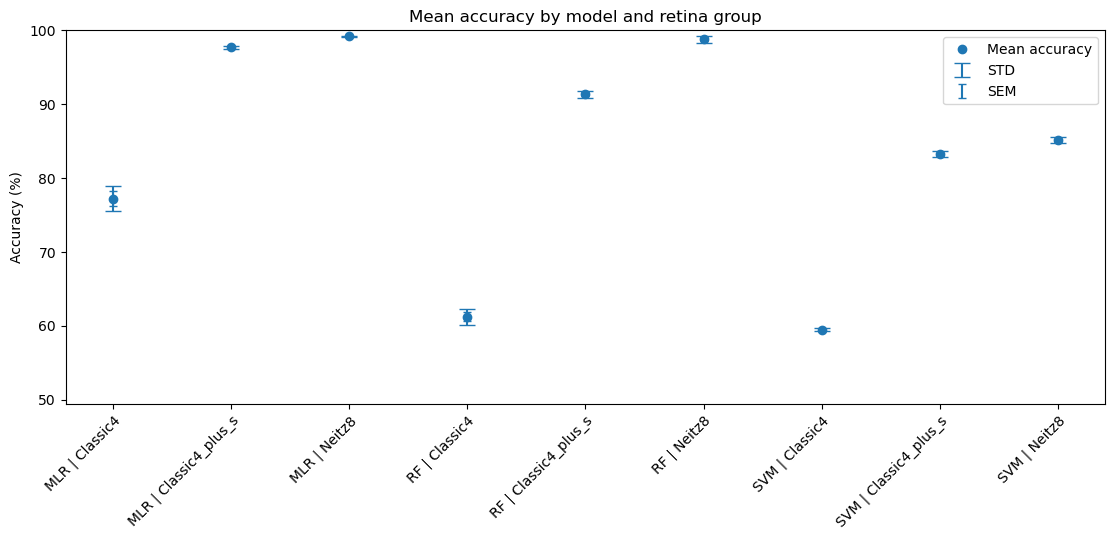

Saved accuracy plot: mlr_svm_rf_compare_20260402_test2/evaluation_outputs/accuracy_dotplot_std_sem.png


,model,group,n_runs,accuracy_mean_percent,accuracy_std_percent,accuracy_sem_percent
0,MLR,Classic4,3,77.225225,1.717298,0.991482
1,MLR,Classic4_plus_s,3,97.693694,0.225045,0.129930
2,MLR,Neitz8,3,99.171171,0.062416,0.036036
3,RF,Classic4,3,61.225225,1.050004,0.606220
4,RF,Classic4_plus_s,3,91.351351,0.495414,0.286027
5,RF,Neitz8,3,98.810811,0.471232,0.272066
6,SVM,Classic4,3,59.459459,0.216216,0.124832
7,SVM,Classic4_plus_s,3,83.243243,0.374497,0.216216
8,SVM,Neitz8,3,85.153153,0.347519,0.200640


In [10]:
# Cell 10 — Build, display, and save the accuracy summary figures  # Plot case-level mean accuracy as dots with STD and SEM error bars.
if "ACCURACY_SUMMARY_DF" not in globals() or len(ACCURACY_SUMMARY_DF) == 0:  # Stop when the case-level accuracy summary is missing.
    raise RuntimeError("Please run Cell 7 before building the accuracy figures.")  # Explain which earlier step is required first.
# ---  # Separate the code into small readable sections.
accuracy_plot_path = NOTEBOOK_OUTPUT_DIR / EVAL_OUTPUT_FOLDER_NAME / "accuracy_dotplot_std_sem.png"  # Build the main shared accuracy-dot-plot output path.
plot_df = ACCURACY_SUMMARY_DF.copy().sort_values(["model", "group"], kind="mergesort").reset_index(drop=True)  # Build one stable plotting dataframe ordered by model and group.
plot_df["case_label"] = plot_df["model"].astype(str) + " | " + plot_df["group"].astype(str)  # Build one readable x-axis label per model-group case.
x_positions = np.arange(len(plot_df), dtype=float)  # Create one numeric x position per plotted case.
# ---  # Separate the code into small readable sections.
fig, ax = plt.subplots(figsize=(max(8.0, 1.25 * len(plot_df)), 5.5))  # Create one figure that expands horizontally as more cases are selected.
ax.plot(x_positions, plot_df["accuracy_mean_percent"].to_numpy(dtype=float), "o", label="Mean accuracy")  # Plot one circle marker at the mean accuracy for each case.
if SHOW_STD_ERROR_BARS:  # Add the requested standard-deviation error bars when enabled.
    ax.errorbar(x_positions, plot_df["accuracy_mean_percent"].to_numpy(dtype=float), yerr=plot_df["accuracy_std_percent"].to_numpy(dtype=float), fmt="none", capsize=6, label="STD")  # Draw the outer standard-deviation error bars around each mean dot.
if SHOW_SEM_ERROR_BARS:  # Add the requested standard-error error bars when enabled.
    ax.errorbar(x_positions, plot_df["accuracy_mean_percent"].to_numpy(dtype=float), yerr=plot_df["accuracy_sem_percent"].to_numpy(dtype=float), fmt="none", capsize=3, label="SEM")  # Draw the inner standard-error error bars around each mean dot.
ax.set_xticks(x_positions)  # Put one x tick at each plotted case location.
ax.set_xticklabels(plot_df["case_label"].tolist(), rotation=45, ha="right", rotation_mode="anchor")  # Show the readable case labels under the x ticks.
ax.set_ylabel("Accuracy (%)")  # Label the y axis in percent units.
ax.set_title("Mean accuracy by model and retina group")  # Add a descriptive plot title.
ax.set_ylim(bottom=max(0.0, float(np.nanmin(plot_df["accuracy_mean_percent"].to_numpy(dtype=float)) - 10.0)), top=min(100.0, float(np.nanmax(plot_df["accuracy_mean_percent"].to_numpy(dtype=float)) + 10.0)))  # Keep the y-axis limits focused on the observed accuracy range while staying inside 0 to 100.
ax.legend()  # Show the legend that distinguishes the mean dots, STD bars, and SEM bars.
fig.tight_layout()  # Tighten the layout so the rotated x labels fit cleanly.
fig.savefig(accuracy_plot_path, dpi=200, bbox_inches="tight")  # Save the main shared accuracy-dot plot to disk.
plt.show()  # Display the finished accuracy-dot plot inline.
plt.close(fig)  # Close the figure so repeated saves do not stack open figures in memory.
# ---  # Separate the code into small readable sections.
print("Saved accuracy plot:", accuracy_plot_path)  # Show where the main shared accuracy-dot plot was saved.
display(plot_df[["model", "group", "n_runs", "accuracy_mean_percent", "accuracy_std_percent", "accuracy_sem_percent"]])  # Display the plotted case-level accuracy values for quick inspection.

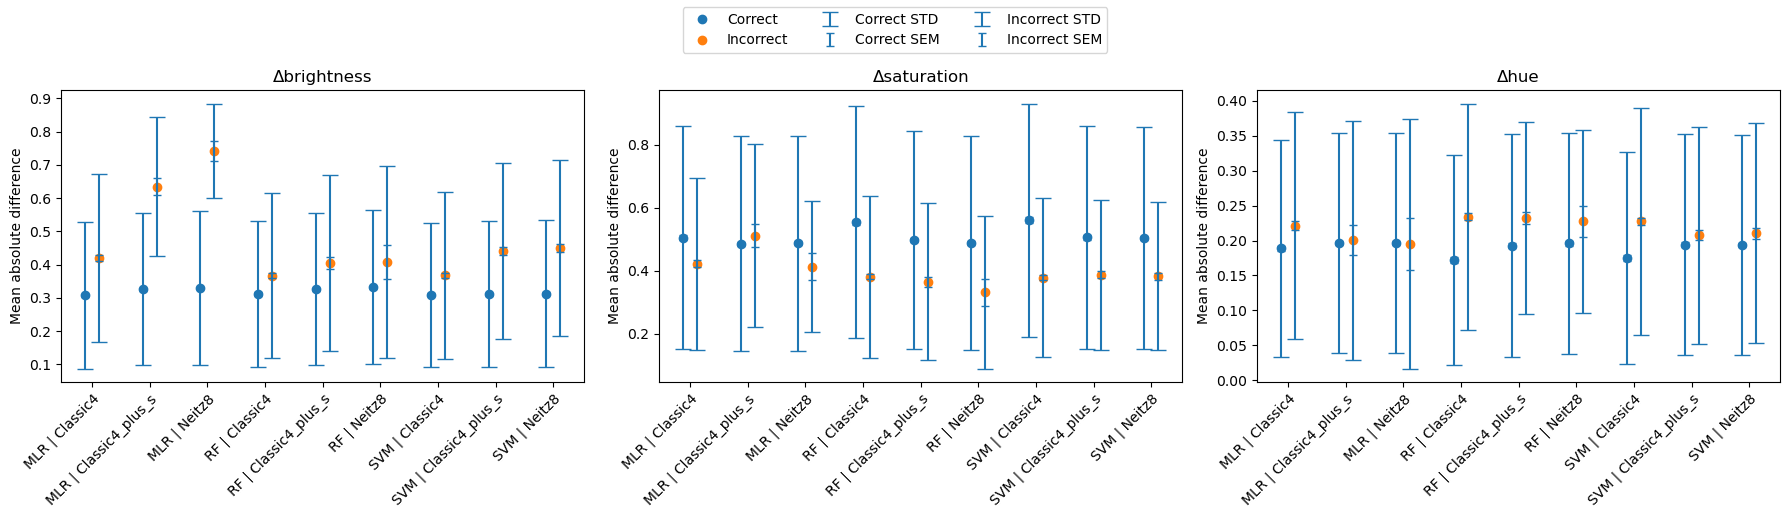

Saved contrast long table: mlr_svm_rf_compare_20260402_test2/evaluation_outputs/contrast_analysis/contrast_distribution_long.csv
Saved contrast summary table: mlr_svm_rf_compare_20260402_test2/evaluation_outputs/contrast_analysis/contrast_summary.csv
Saved contrast summary plot: mlr_svm_rf_compare_20260402_test2/evaluation_outputs/contrast_analysis/contrast_summary_dotplot_std_sem.png


,model,group,metric_name,outcome,n_rows,metric_mean,metric_median,metric_std,metric_sem
0,MLR,Classic4,delta_brightness,correct,2143,0.307486,0.274490,0.220480,0.004763
1,MLR,Classic4,delta_brightness,incorrect,632,0.419386,0.388776,0.253105,0.010068
2,MLR,Classic4,delta_hue,correct,2143,0.188832,0.166667,0.155604,0.003361
3,MLR,Classic4,delta_hue,incorrect,632,0.221255,0.166667,0.161870,0.006439
4,MLR,Classic4,delta_saturation,correct,2143,0.505366,0.500000,0.354999,0.007669
5,MLR,Classic4,delta_saturation,incorrect,632,0.422152,0.400000,0.273195,0.010867
6,MLR,Classic4_plus_s,delta_brightness,correct,2711,0.325855,0.300000,0.228848,0.004395
7,MLR,Classic4_plus_s,delta_brightness,incorrect,64,0.634407,0.800000,0.210073,0.026259
8,MLR,Classic4_plus_s,delta_hue,correct,2711,0.196115,0.166667,0.157313,0.003021
9,MLR,Classic4_plus_s,delta_hue,incorrect,64,0.200521,0.166667,0.171052,0.021382


In [14]:
# Cell 11 — Build, display, and save the contrast-analysis outputs  # Compare delta brightness, saturation, and hue for correct versus incorrect stimuli in each case.
if not INCLUDE_CONTRAST_ANALYSIS:  # Stop early when contrast analysis is disabled at the top of the notebook.
    print("Contrast analysis is disabled by the INCLUDE_CONTRAST_ANALYSIS setting in Cell 1.")  # Explain why this cell is not doing any work.
elif "RUN_PREDICTIONS_LONG_DF" not in globals() or len(RUN_PREDICTIONS_LONG_DF) == 0:  # Stop when the reconstructed run-prediction table is missing.
    raise RuntimeError("Please run Cell 6 before building the contrast-analysis outputs.")  # Explain which earlier step is required first.
else:  # Continue into the contrast-analysis workflow when the required inputs are available.
    contrast_output_dir = NOTEBOOK_OUTPUT_DIR / EVAL_OUTPUT_FOLDER_NAME / "contrast_analysis"  # Build the shared contrast-analysis output folder path.
    contrast_long_df = RUN_PREDICTIONS_LONG_DF[["model", "group", "run_key", "stim_ID", "is_correct", "delta_brightness", "delta_saturation", "delta_hue"]].copy()  # Keep only the columns needed for the contrast analyses.
    contrast_long_df["outcome"] = np.where(contrast_long_df["is_correct"].astype(bool), "correct", "incorrect")  # Add one readable correct-versus-incorrect outcome column.
    stacked_parts = []  # Collect one long-format metric table per contrast metric.
    for metric_name in ["delta_brightness", "delta_saturation", "delta_hue"]:  # Stack the three contrast metrics into one long-format table.
        metric_df = contrast_long_df[["model", "group", "run_key", "stim_ID", "outcome", metric_name]].copy()  # Keep the current metric together with the core identifiers.
        metric_df = metric_df.rename(columns={metric_name: "metric_value"})  # Rename the current metric column to one shared long-format value column.
        metric_df["metric_name"] = str(metric_name)  # Record which contrast metric each long-format row belongs to.
        stacked_parts.append(metric_df)  # Save the current long-format metric table for later concatenation.
    CONTRAST_DISTRIBUTION_LONG_DF = pd.concat(stacked_parts, ignore_index=True) if len(stacked_parts) > 0 else pd.DataFrame()  # Combine the metric-specific long tables into one stacked long-format contrast table.
    CONTRAST_DISTRIBUTION_LONG_DF["metric_value"] = pd.to_numeric(CONTRAST_DISTRIBUTION_LONG_DF["metric_value"], errors="coerce")  # Convert the stacked metric values to numeric form.
    CONTRAST_DISTRIBUTION_LONG_DF = CONTRAST_DISTRIBUTION_LONG_DF.loc[~CONTRAST_DISTRIBUTION_LONG_DF["metric_value"].isna()].copy()  # Drop contrast rows that still lack a numeric value.
    contrast_summary_rows = []  # Collect one short summary row per case, metric, and outcome.
    for (model_name, group_name, metric_name, outcome_name), summary_df in CONTRAST_DISTRIBUTION_LONG_DF.groupby(["model", "group", "metric_name", "outcome"], sort=True):  # Summarize one case-metric-outcome combination at a time.
        metric_series = pd.to_numeric(summary_df["metric_value"], errors="coerce").dropna()  # Read the current metric values as one clean numeric series.
        contrast_summary_rows.append({"model": str(model_name), "group": str(group_name), "metric_name": str(metric_name), "outcome": str(outcome_name), "n_rows": int(len(metric_series)), "metric_mean": float(metric_series.mean()) if len(metric_series) > 0 else np.nan, "metric_median": float(metric_series.median()) if len(metric_series) > 0 else np.nan, "metric_std": float(metric_series.std(ddof=1)) if len(metric_series) > 1 else 0.0, "metric_sem": sem_from_series(metric_series)})  # Save the short summary values for the current case-metric-outcome combination.
    CONTRAST_SUMMARY_DF = pd.DataFrame(contrast_summary_rows).sort_values(["model", "group", "metric_name", "outcome"], kind="mergesort").reset_index(drop=True) if len(contrast_summary_rows) > 0 else pd.DataFrame(columns=["model", "group", "metric_name", "outcome", "n_rows", "metric_mean", "metric_median", "metric_std", "metric_sem"])  # Combine the short contrast-summary rows into one stable table.
    contrast_long_path = contrast_output_dir / "contrast_distribution_long.csv"  # Build the stacked long-format contrast-table CSV path.
    contrast_summary_path = contrast_output_dir / "contrast_summary.csv"  # Build the short contrast-summary CSV path.
    CONTRAST_DISTRIBUTION_LONG_DF.to_csv(contrast_long_path, index=False)  # Save the stacked long-format contrast table to disk.
    CONTRAST_SUMMARY_DF.to_csv(contrast_summary_path, index=False)  # Save the short contrast-summary table to disk.
    for (model_name, group_name), case_df in CONTRAST_DISTRIBUTION_LONG_DF.groupby(["model", "group"], sort=True):  # Build one matched three-panel distribution figure per case.
        fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.8), sharex=False)  # Create one row of three panels for brightness, saturation, and hue.
        for axis_obj, metric_name in zip(axes, ["delta_brightness", "delta_saturation", "delta_hue"]):  # Draw one distribution panel for each contrast metric.
            metric_case_df = case_df.loc[case_df["metric_name"].astype(str) == str(metric_name)].copy()  # Keep only the current metric rows for the current case.
            correct_values = pd.to_numeric(metric_case_df.loc[metric_case_df["outcome"].astype(str) == "correct", "metric_value"], errors="coerce").dropna().to_numpy(dtype=float)  # Read the correct-stimulus values for the current metric.
            incorrect_values = pd.to_numeric(metric_case_df.loc[metric_case_df["outcome"].astype(str) == "incorrect", "metric_value"], errors="coerce").dropna().to_numpy(dtype=float)  # Read the incorrect-stimulus values for the current metric.
            axis_obj.boxplot([correct_values, incorrect_values], tick_labels=["Correct", "Incorrect"])  # Draw a simple boxplot comparison for correct versus incorrect stimuli.
            if len(correct_values) > 0:  # Overlay jittered point values when correct-stimulus data exist.
                axis_obj.plot(np.random.normal(1.0, 0.03, size=len(correct_values)), correct_values, "o", alpha=0.25, markersize=3)  # Add lightly jittered correct-stimulus points over the boxplot.
            if len(incorrect_values) > 0:  # Overlay jittered point values when incorrect-stimulus data exist.
                axis_obj.plot(np.random.normal(2.0, 0.03, size=len(incorrect_values)), incorrect_values, "o", alpha=0.25, markersize=3)  # Add lightly jittered incorrect-stimulus points over the boxplot.
            axis_obj.set_title(metric_name.replace("delta_", "Δ").replace("_", " "))  # Add a readable metric title above the current panel.
            axis_obj.set_ylabel("Absolute difference")  # Label the y axis as an absolute object-background difference.
        fig.suptitle(f"{model_name} | {group_name} | Correct vs incorrect stimulus differences")  # Add a shared case-level title above the three-panel figure.
        fig.tight_layout()  # Tighten the layout so the panel labels and title fit cleanly.
        figure_path = contrast_output_dir / f"contrast_distribution_{sanitize_name(model_name)}_{sanitize_name(group_name)}.png"  # Build the saved three-panel distribution-figure path for the current case.
        fig.savefig(figure_path, dpi=200, bbox_inches="tight")  # Save the finished three-panel distribution figure to disk.
        plt.close(fig)  # Close the figure so repeated saves do not stack open figures in memory.
    summary_plot_path = contrast_output_dir / "contrast_summary_dotplot_std_sem.png"  # Build the shared summary dot-plot output path for the contrast analysis.
    fig, axes = plt.subplots(1, 3, figsize=(18.0, 5.2), sharey=False)  # Create one row of three summary panels, one per contrast metric.
    ordered_cases = CONTRAST_SUMMARY_DF[["model", "group"]].drop_duplicates().sort_values(["model", "group"], kind="mergesort").reset_index(drop=True)  # Build the stable ordered case list used across all summary panels.
    ordered_cases["case_label"] = ordered_cases["model"].astype(str) + " | " + ordered_cases["group"].astype(str)  # Build the readable case labels used on the x axis.
    for axis_obj, metric_name in zip(axes, ["delta_brightness", "delta_saturation", "delta_hue"]):  # Draw one summary panel for each contrast metric.
        metric_summary_df = CONTRAST_SUMMARY_DF.loc[CONTRAST_SUMMARY_DF["metric_name"].astype(str) == str(metric_name)].copy()  # Keep only the current metric rows for the summary panel.
        for offset_value, outcome_name in [(-0.12, "correct"), (0.12, "incorrect")]:  # Plot correct and incorrect outcomes side by side inside the same panel.
            outcome_df = ordered_cases.merge(metric_summary_df.loc[metric_summary_df["outcome"].astype(str) == str(outcome_name)], on=["model", "group"], how="left")  # Align the current metric-outcome rows to the stable ordered case list.
            x_values = np.arange(len(outcome_df), dtype=float) + float(offset_value)  # Offset the x positions so correct and incorrect dots do not overlap.
            axis_obj.plot(x_values, outcome_df["metric_mean"].to_numpy(dtype=float), "o", label=outcome_name.title())  # Plot one circle marker at the mean metric value for each case and outcome.
            if SHOW_STD_ERROR_BARS:  # Add standard-deviation error bars around the mean dots when requested.
                axis_obj.errorbar(x_values, outcome_df["metric_mean"].to_numpy(dtype=float), yerr=outcome_df["metric_std"].to_numpy(dtype=float), fmt="none", capsize=6, label=f"{outcome_name.title()} STD")  # Draw the standard-deviation error bars for the current outcome.
            if SHOW_SEM_ERROR_BARS:  # Add standard-error error bars around the mean dots when requested.
                axis_obj.errorbar(x_values, outcome_df["metric_mean"].to_numpy(dtype=float), yerr=outcome_df["metric_sem"].to_numpy(dtype=float), fmt="none", capsize=3, label=f"{outcome_name.title()} SEM")  # Draw the standard-error error bars for the current outcome.
        axis_obj.set_xticks(np.arange(len(ordered_cases), dtype=float))  # Put one x tick at each ordered case location.
        axis_obj.set_xticklabels(ordered_cases["case_label"].tolist(), rotation=45, ha="right", rotation_mode="anchor")  # Show the readable ordered case labels under the x ticks.
        axis_obj.set_title(metric_name.replace("delta_", "Δ").replace("_", " "))  # Add a readable metric title above the current summary panel.
        axis_obj.set_ylabel("Mean absolute difference")  # Label the y axis as a mean absolute object-background difference.
    handles, labels = axes[0].get_legend_handles_labels()  # Read the legend entries from the first summary panel.
    unique_legend = dict(zip(labels, handles))  # Keep one handle per legend label so the shared legend does not repeat entries.
    fig.legend(unique_legend.values(), unique_legend.keys(), loc="upper center", ncol=3)  # Add one shared legend above the summary panels.
    fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.90])  # Tighten the layout while leaving room for the shared legend.
    fig.savefig(summary_plot_path, dpi=200, bbox_inches="tight")  # Save the finished contrast-summary dot plot to disk.
    plt.show()  # Display the finished contrast-summary dot plot inline.
    plt.close(fig)  # Close the figure so repeated saves do not stack open figures in memory.
    print("Saved contrast long table:", contrast_long_path)  # Show where the stacked long-format contrast table was saved.
    print("Saved contrast summary table:", contrast_summary_path)  # Show where the short contrast-summary table was saved.
    print("Saved contrast summary plot:", summary_plot_path)  # Show where the contrast-summary dot plot was saved.
    display(CONTRAST_SUMMARY_DF)  # Display the short contrast-summary table for quick inspection.

In [15]:
# Cell 12 — Final output summary and saved-file manifest  # Collect the key saved outputs, save a manifest table, and display the final notebook summaries.
if "ACTIVE_EVAL_SUMMARY_LONG_DF" not in globals() or len(ACTIVE_EVAL_SUMMARY_LONG_DF) == 0:  # Stop when the aggregated long confusion summary is missing.
    raise RuntimeError("Please run Cell 7 before building the final output manifest.")  # Explain which earlier step is required first.
# ---  # Separate the code into small readable sections.
summaries_dir = NOTEBOOK_OUTPUT_DIR / "summaries"  # Build the shared summaries folder path.
eval_output_dir = NOTEBOOK_OUTPUT_DIR / EVAL_OUTPUT_FOLDER_NAME  # Build the shared evaluation-output folder path.
difference_output_dir = eval_output_dir / "difference_matrices"  # Build the shared difference-matrix output folder path.
contrast_output_dir = eval_output_dir / "contrast_analysis"  # Build the shared contrast-analysis output folder path.
manifest_rows = []  # Collect one manifest row per saved file.
for file_path in sorted(NOTEBOOK_OUTPUT_DIR.rglob("*")):  # Walk through every saved file inside the notebook-output folder.
    if file_path.is_dir():  # Skip folders and keep only real files in the manifest.
        continue  # Move on to the next saved path.
    manifest_rows.append({"category": str(file_path.parent.relative_to(NOTEBOOK_OUTPUT_DIR)), "filename": str(file_path.name), "path": str(file_path), "exists": bool(file_path.exists()), "size_bytes": int(file_path.stat().st_size) if file_path.exists() else np.nan})  # Save one readable manifest row for the current file.
OUTPUT_MANIFEST_DF = pd.DataFrame(manifest_rows).sort_values(["category", "filename"], kind="mergesort").reset_index(drop=True) if len(manifest_rows) > 0 else pd.DataFrame(columns=["category", "filename", "path", "exists", "size_bytes"])  # Combine the saved file rows into one stable manifest table.
output_manifest_path = NOTEBOOK_OUTPUT_DIR / "output_manifest.csv"  # Build the saved output-manifest CSV path.
OUTPUT_MANIFEST_DF.to_csv(output_manifest_path, index=False)  # Save the output-manifest table to disk.
# ---  # Separate the code into small readable sections.
selected_case_count = int(ACTIVE_EVAL_SUMMARY_LONG_DF[["model", "group"]].drop_duplicates().shape[0])  # Count how many model-group cases were aggregated in this notebook run.
difference_pair_count = int(DIFFERENCE_MATRICES_SUMMARY_DF.shape[0]) if "DIFFERENCE_MATRICES_SUMMARY_DF" in globals() else 0  # Count how many difference-matrix group pairs were built in this notebook run.
contrast_case_count = int(CONTRAST_SUMMARY_DF[["model", "group"]].drop_duplicates().shape[0]) if "CONTRAST_SUMMARY_DF" in globals() else 0  # Count how many cases contributed contrast-analysis outputs in this notebook run.
final_summary_rows = [{"notebook_name": "MLR_SVM_RF_compare_v4.ipynb", "gray_handling_mode": str(EVAL_MODE_SUFFIX), "aggregation_method": str(AGGREGATION_METHOD), "label_source": str(LABEL_SOURCE_SUFFIX), "n_selected_runs": int(SELECTED_RUNS_DF.shape[0]) if "SELECTED_RUNS_DF" in globals() else 0, "n_cases": selected_case_count, "n_difference_pairs": difference_pair_count, "n_contrast_cases": contrast_case_count, "contrast_analysis_enabled": bool(INCLUDE_CONTRAST_ANALYSIS), "summary_long_path": str(summaries_dir / NOTEBOOK_SUMMARY_FILE_NAME), "accuracy_summary_path": str(eval_output_dir / "accuracy_summary.csv"), "difference_summary_path": str(difference_output_dir / "difference_matrices_summary.csv"), "contrast_summary_path": str(contrast_output_dir / "contrast_summary.csv")}]  # Build one one-row notebook-level summary table.
FINAL_NOTEBOOK_SUMMARY_DF = pd.DataFrame(final_summary_rows)  # Convert the notebook-level summary row into a dataframe.
final_notebook_summary_path = NOTEBOOK_OUTPUT_DIR / "final_notebook_summary.csv"  # Build the saved final notebook-summary CSV path.
FINAL_NOTEBOOK_SUMMARY_DF.to_csv(final_notebook_summary_path, index=False)  # Save the one-row final notebook-summary table to disk.
# ---  # Separate the code into small readable sections.
print("Saved output manifest:", output_manifest_path)  # Show where the output-manifest CSV was saved.
print("Saved final notebook summary:", final_notebook_summary_path)  # Show where the final notebook-summary CSV was saved.
display(FINAL_NOTEBOOK_SUMMARY_DF)  # Display the one-row final notebook summary for quick inspection.
display(OUTPUT_MANIFEST_DF)  # Display the saved output-manifest table for quick inspection.

Saved output manifest: mlr_svm_rf_compare_20260402_test2/output_manifest.csv
Saved final notebook summary: mlr_svm_rf_compare_20260402_test2/final_notebook_summary.csv


,notebook_name,gray_handling_mode,aggregation_method,label_source,n_selected_runs,n_cases,n_difference_pairs,n_contrast_cases,contrast_analysis_enabled,summary_long_path,accuracy_summary_path,difference_summary_path,contrast_summary_path
0,MLR_SVM_RF_compare_v4.ipynb,gray_merged,pooled_counts,auto_labels,27,9,9,9,True,mlr_svm_rf_compare_20260402_test2/summaries/co...,mlr_svm_rf_compare_20260402_test2/evaluation_o...,mlr_svm_rf_compare_20260402_test2/evaluation_o...,mlr_svm_rf_compare_20260402_test2/evaluation_o...


,category,filename,path,exists,size_bytes
0,.,final_notebook_summary.csv,mlr_svm_rf_compare_20260402_test2/final_notebo...,True,659
1,.,output_manifest.csv,mlr_svm_rf_compare_20260402_test2/output_manif...,True,12166
2,evaluation_outputs,accuracy_by_run.csv,mlr_svm_rf_compare_20260402_test2/evaluation_o...,True,4327
3,evaluation_outputs,accuracy_dotplot_std_sem.png,mlr_svm_rf_compare_20260402_test2/evaluation_o...,True,111439
4,evaluation_outputs,accuracy_summary.csv,mlr_svm_rf_compare_20260402_test2/evaluation_o...,True,1406
5,evaluation_outputs,auto_labels_cm_pct_MLR_Classic4_gray_merged_an...,mlr_svm_rf_compare_20260402_test2/evaluation_o...,True,81642
6,evaluation_outputs,auto_labels_cm_pct_MLR_Classic4_gray_merged_bl...,mlr_svm_rf_compare_20260402_test2/evaluation_o...,True,59944
7,evaluation_outputs,auto_labels_cm_pct_MLR_Classic4_plus_s_gray_me...,mlr_svm_rf_compare_20260402_test2/evaluation_o...,True,76965
8,evaluation_outputs,auto_labels_cm_pct_MLR_Classic4_plus_s_gray_me...,mlr_svm_rf_compare_20260402_test2/evaluation_o...,True,60907
9,evaluation_outputs,auto_labels_cm_pct_MLR_Neitz8_gray_merged_anno...,mlr_svm_rf_compare_20260402_test2/evaluation_o...,True,75354
